In [6]:
def check_credentials_file(path):
    try:
        with open(path, 'r') as f:
            content = f.read()
            print("File exists and is readable")
            # Print first 100 chars to verify content (don't print full key)
            print(f"File starts with: {content[:100]}...")
            return True
    except Exception as e:
        print(f"Error reading credentials file: {e}")
        return False

check_credentials_file('resources\legal-research-platform-firebase-adminsdk-fbsvc-46a9ab3605.json')

File exists and is readable
File starts with: {
  "type": "service_account",
  "project_id": "legal-research-platform",
  "private_key_id": "46a9a...


True

In [35]:
def setup_ground_truth(rag_system):
    # --- Ground Truth for Case ID: 8fb1373c-2b19-4df4-bbcc-40b0720dc9b3 (Murder Conviction Appeal) ---
    rag_system.add_ground_truth_with_scores(
        "What are the legal principles for dismissing an appeal in a murder case based on a sole eyewitness?",
        {
            '8fb1373c-2b19-4df4-bbcc-40b0720dc9b3': 1.0,  # Directly discusses this.
            '4c9fba4d-eee6-4afa-8020-a56053595d73': 0.7,   # Relevant as it also deals with a sole eyewitness in a murder case.
            'b8e84465-1397-4497-ba67-52f06e90ca24': 0.5    # Discusses exceptions to murder like grave and sudden provocation.
        }
    )
    rag_system.add_ground_truth_with_scores(
        "Find a case where a manna knife was used as a weapon and recovered under Section 27 of the Evidence Ordinance.",
        {
            '8fb1373c-2b19-4df4-bbcc-40b0720dc9b3': 1.0  # Explicitly matches all keywords.
        }
    )

    # --- Ground Truth for Case ID: f377d509-ea0d-4a2f-9e7a-4d2a14515d19 (Public Service Promotion Dispute) ---
    rag_system.add_ground_truth_with_scores(
        "How does deferment of salary increments affect the calculation of 'satisfactory service' for public officer promotions?",
        {
            'f377d509-ea0d-4a2f-9e7a-4d2a14515d19': 1.0,  # This is the central legal question of the case.
            'aad05a37-c875-47bc-b999-9c7d7f78a36d': 0.4   # Also deals with public service promotions but on different grounds.
        }
    )
    rag_system.add_ground_truth_with_scores(
        "What is the role of Rule 186 of the Public Service Commission Procedural Rules in promotion disputes?",
        {
            'f377d509-ea0d-4a2f-9e7a-4d2a14515d19': 1.0 # This rule is explicitly cited and interpreted.
        }
    )

    # --- Ground Truth for Case ID: 3f222e28-d9a0-452e-aa98-498d5656613e & 70e90de1-f93f-48d9-840a-6a2b1b067278 (State Lands Recovery) ---
    rag_system.add_ground_truth_with_scores(
        "What are the legal limitations of an inquiry under Section 9 of the State Lands (Recovery of Possession) Act?",
        {
            '3f222e28-d9a0-452e-aa98-498d5656613e': 1.0,  # Directly quotes and analyzes Section 9.
            '70e90de1-f93f-48d9-840a-6a2b1b067278': 1.0,  # Also directly quotes and analyzes Section 9.
            'eaaf5922-459d-46c6-8a6d-7d943cf59802': 0.8,   # Discusses the same act but focuses on the quit notice under Section 3.
            '7b6aa5f6-c52c-4eec-8b58-eb95316b4072': 0.7    # Also about the same act, but from a different angle.
        }
    )
    rag_system.add_ground_truth_with_scores(
        "Can a competent authority issue a new quit notice after a previous one was quashed by a writ of Certiorari?",
        {
            '3f222e28-d9a0-452e-aa98-498d5656613e': 1.0, # This is a key finding in the judgment.
            '70e90de1-f93f-48d9-840a-6a2b1b067278': 1.0  # Same facts, same finding.
        }
    )
    
    # --- Ground Truth for Case ID: 9eaa002e-2133-40a3-97ec-3bf16d5829f8 (Bail Act vs Criminal Procedure Code) ---
    rag_system.add_ground_truth_with_scores(
        "Which law prevails in a conflict between the Bail Act No. 30 of 1997 and Section 263 of the Code of Criminal Procedure Act?",
        {
            '9eaa002e-2133-40a3-97ec-3bf16d5829f8': 1.0  # This is the central legal principle discussed and decided.
        }
    )
    rag_system.add_ground_truth_with_scores(
        "What are the mandatory requirements under Section 14 of the Bail Act for canceling a subsisting bail order?",
        {
            '9eaa002e-2133-40a3-97ec-3bf16d5829f8': 1.0 # The case explicitly lists and analyzes the requirements of Section 14.
        }
    )

    # --- Ground Truth for Case ID: 2d8f6172-6e23-4841-8b6e-70952dfc1cdc (Evidence Corroboration in Sexual Abuse Case) ---
    rag_system.add_ground_truth_with_scores(
        "What is the legal standard for corroboration of a victim's video testimony under Section 163A(5) of the Evidence Ordinance?",
        {
            '2d8f6172-6e23-4841-8b6e-70952dfc1cdc': 1.0, # The entire case revolves around this specific section.
            '1fd3711c-cee9-4d59-9023-a32cd006f8d1': 0.6  # Also a sexual abuse case but discusses corroboration in a different context (history to JMO).
        }
    )
    rag_system.add_ground_truth_with_scores(
        "Distinguish between evidence of 'consistency' and 'corroboration' in sexual assault cases.",
        {
            '2d8f6172-6e23-4841-8b6e-70952dfc1cdc': 1.0 # This distinction is a key part of the legal reasoning.
        }
    )

    # --- Ground Truth for Case ID: 84e32ca3-6e0c-43c9-ac73-9e38f0816370 (BOI Tax Exemption) ---
    rag_system.add_ground_truth_with_scores(
        "Does a supplementary agreement with the BOI automatically extend tax exemptions from a principal agreement to new business activities?",
        {
            '84e32ca3-6e0c-43c9-ac73-9e38f0816370': 1.0, # This is the core issue of the tax dispute.
            'dc6ff29a-02b1-4d34-8567-498ee09e229b': 0.5  # Also a BOI case but deals with VAT and agency agreements.
        }
    )

    # --- Ground Truth for Case ID: 8a23d9c9-b5b6-4c47-87ef-ab9d38ab5272 (School Admission Dispute) ---
    rag_system.add_ground_truth_with_scores(
        "What constitutes 'proof of residence' for school admissions under the close proximity category according to circular 29/2019?",
        {
            '8a23d9c9-b5b6-4c47-87ef-ab9d38ab5272': 1.0, # The case meticulously analyzes the requirements of physical inspection and documentation.
            'cef80e03-1e21-453d-b2a8-76f0ddc84ff9': 0.6  # Another school admission case, but focuses on religious quotas.
        }
    )
    rag_system.add_ground_truth_with_scores(
        "Can an applicant claim legitimate expectation for school admission based solely on marks obtained at the initial interview?",
        {
            '8a23d9c9-b5b6-4c47-87ef-ab9d38ab5272': 1.0 # The judgment directly addresses and refutes this claim.
        }
    )

    # --- Ground Truth for Case ID: 4c9fba4d-eee6-4afa-8020-a56053595d73 (Unlawful Assembly and Murder) ---
    rag_system.add_ground_truth_with_scores(
        "What is the standard of proof for convicting based on a sole eyewitness in a criminal case?",
        {
            '4c9fba4d-eee6-4afa-8020-a56053595d73': 1.0, # Discusses this in detail, citing Section 134 of the Evidence Ordinance.
            '8fb1373c-2b19-4df4-bbcc-40b0720dc9b3': 0.8  # Also relevant as it discusses the same principle.
        }
    )
    rag_system.add_ground_truth_with_scores(
        "Find a case where a dying declaration was excluded from evidence.",
        {
            '4c9fba4d-eee6-4afa-8020-a56053595d73': 1.0 # This case explicitly excludes the dying declaration evidence.
        }
    )

    # --- Ground Truth for Case ID: 6aea5179-112f-4db6-a5d5-5624f2f8ff5c (EPF and Charitable Organizations) ---
    rag_system.add_ground_truth_with_scores(
        "Under what conditions is a charitable organization exempt from paying EPF contributions?",
        {
            '6aea5179-112f-4db6-a5d5-5624f2f8ff5c': 1.0 # The case defines 'charitable institution' and applies the EPF Act to it.
        }
    )

    # --- Ground Truth for Case ID: 766f067d-f06a-4953-bbe3-444a2c498bd6 (Recovery of Loan from Provident Fund) ---
    rag_system.add_ground_truth_with_scores(
        "Can an employer recover an employee loan from an approved Private Provident Fund like the MSPS?",
        {
            '766f067d-f06a-4953-bbe3-444a2c498bd6': 1.0 # This case directly interprets Rule 43 of the MSPS and Section 27 of the EPF Act to answer this.
        }
    )

    # --- Ground Truth for Case ID: 9f8a8858-7dc2-435e-b914-8dea2058034e (Bribery Commission Investigation Procedure) ---
    rag_system.add_ground_truth_with_scores(
        "Is a directive from all three commissioners required to commence an investigation under the Bribery Act?",
        {
            '9f8a8858-7dc2-435e-b914-8dea2058034e': 1.0, # This case provides a detailed analysis of CIABOC Act sections 2, 3, 4, 5, 11, 12, and 16 to answer this.
            'a111fc60-fcf9-4e9d-b2d5-dfe223d04832': 1.0, # Identical case, identical reasoning.
            '4ea5ae9c-ecd2-42cf-8001-6e843b357b65': 1.0, # Identical case, identical reasoning.
            'a57c0ed8-1ccc-4082-a34c-b445d62dd4ef': 0.8  # Also deals with CIABOC but from a different procedural angle.
        }
    )

In [28]:
import asyncio
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple, Union, Any
from enum import Enum
import numpy as np
from abc import ABC, abstractmethod
from sentence_transformers import SentenceTransformer
import logging
from datetime import datetime, timedelta
import json
import re
from transformers import AutoTokenizer, AutoModelForMaskedLM
from neo4j import GraphDatabase
from pinecone import Pinecone
import torch
import nest_asyncio
import firebase_admin
from firebase_admin import credentials, firestore

# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Pinecone credentials
PINECONE_API_KEY = "pcsk_2it9oG_RzRNfQdLGg9jUen7wW6viE9JpLRgVTHtWbTZhomuZKmhuyYnrh8GgMyrHJMz37Q"
PINECONE_CASE_DENSE_INDEX = f"law-cases-dense"
PINECONE_CASE_SPARSE_INDEX = f"law-cases-sparse"
PINECONE_ACTS_DENSE_INDEX = f"law-acts-dense"
PINECONE_ACTS_SPARSE_INDEX = f"law-acts-sparse"
PINECONE_DENSE_EMBED_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
PINECONE_SPARSE_EMBED_MODEL = "naver/splade-cocondenser-ensembledistil"

# Neo4j credentials and URI
NEO4J_URI = "neo4j+s://66d16355.databases.neo4j.io"
NEO4J_USERNAME = "neo4j"
NEO4J_PASSWORD = "G4UXZ6KLGd1dzo57rp6ITypJHZ37aM1fn-exAWdw3p8"
NEO4J_DATABASE = "neo4j"

FIRESTORE_PROJECT_ID = "legal-research-platform"
FIRESTORE_CREDENTIALS_PATH = "resources\legal-research-platform-firebase-adminsdk-fbsvc-46a9ab3605.json"


class QueryIntent(Enum):
    DOCTRINAL = "doctrinal"
    PRECEDENTIAL = "precedential"
    PROCEDURAL = "procedural"
    COMPARATIVE = "comparative"
    MIXED = "mixed"

class DocumentType(Enum):
    CASE = "case"
    ACT = "act"

@dataclass
class QueryContext:
    raw_query: str
    intent: QueryIntent
    complexity_score: float
    legal_domains: List[str]
    jurisdictions: List[str]
    temporal_constraints: Optional[Dict[str, Any]] = None
    extracted_entities: List[str] = field(default_factory=list)

@dataclass
class DocumentMetadata:
    doc_id: str
    doc_type: DocumentType
    title: str
    court_level: Optional[int] = None  # 1=Supreme, 2=High, 3=District
    jurisdiction: str = ""
    date: Optional[datetime] = None
    legal_domains: List[str] = field(default_factory=list)
    act_sections: List[str] = field(default_factory=list)

@dataclass
class RetrievedChunk:
    doc_id: str
    chunk_id: str
    content: str
    metadata: DocumentMetadata
    vector_score: float
    chunk_index: int
    
class KGFeatures:
    def __init__(self):
        self.citation_count: int = 0
        self.act_references: int = 0
        self.judge_count: int = 0
        self.jurisdictional_weight: float = 0.0
        self.authority_score: float = 0.0
        self.recency_boost: float = 0.0

@dataclass
class EnhancedChunk(RetrievedChunk):
    kg_features: KGFeatures = field(default_factory=KGFeatures)
    final_score: float = 0.0

@dataclass
class ReasoningStep:
    step_type: str  # "major_premise", "minor_premise", "application", "conclusion"
    content: str
    doc_id: str
    confidence: float

@dataclass
class ReasoningChain:
    chain_id: str
    steps: List[ReasoningStep]
    chain_strength: float

@dataclass
class ContextBundle:
    core_documents: List[Dict[str, Any]]
    supporting_context: Dict[str, List[Dict[str, Any]]]
    reasoning_chains: List[ReasoningChain]
    provenance_graph: Dict[str, List[str]]
    total_tokens: int

@dataclass
class EvaluationMetrics:
    relevance_scores: List[float]
    precision_at_k: Dict[int, float]
    recall_at_k: Dict[int, float]
    authority_coverage: float
    reasoning_completeness: float
    response_time: float

def embed_text_dense(text: str, model: SentenceTransformer) -> List[float]:
    return model.encode(text).tolist()

def embed_text_sparse(text: str, tokenizer, model) -> Dict[str, List]:
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs).logits.squeeze(0)
    scores = torch.log(1 + torch.relu(outputs))
    max_scores, _ = torch.max(scores, dim=0)
    non_zero_indices = torch.nonzero(max_scores).squeeze(1).tolist()
    non_zero_values = max_scores[non_zero_indices].tolist()
    tokens = tokenizer.convert_ids_to_tokens(non_zero_indices)
    indices = tokenizer.convert_tokens_to_ids(tokens)
    return {
        "values": non_zero_values,
        "indices": indices,
    }

class QueryAnalyzer:
    def __init__(self):
        self.legal_domain_keywords = {
            "contract": ["contract", "agreement", "breach", "consideration", "offer", "acceptance"],
            "tort": ["negligence", "liability", "damages", "duty", "breach"],
            "criminal": ["criminal", "offense", "punishment", "conviction", "sentence"],
            "constitutional": ["constitutional", "fundamental rights", "directive principles"],
            "property": ["property", "ownership", "title", "possession", "transfer"]
        }
        
        self.intent_patterns = {
            QueryIntent.DOCTRINAL: ["interpret", "meaning", "definition", "scope", "provisions"],
            QueryIntent.PRECEDENTIAL: ["precedent", "case law", "judicial", "ruling", "decided"],
            QueryIntent.PROCEDURAL: ["procedure", "process", "steps", "filing", "court"],
            QueryIntent.COMPARATIVE: ["compare", "difference", "similar", "contrast", "versus"]
        }

    def analyze_query(self, query: str) -> QueryContext:
        """Comprehensive query analysis with intent classification"""
        intent = self._classify_intent(query)
        complexity = self._assess_complexity(query)
        domains = self._extract_legal_domains(query)
        jurisdictions = self._extract_jurisdictions(query)
        entities = self._extract_legal_entities(query)

        print("Query Intent:", intent)
        print("Query Complexity:", complexity)
        print("Legal Domains:", domains)
        print("Jurisdictions:", jurisdictions)
        print("Legal Entities:", entities)
        
        return QueryContext(
            raw_query=query,
            intent=intent,
            complexity_score=complexity,
            legal_domains=domains,
            jurisdictions=jurisdictions,
            extracted_entities=entities
        )
    
    def _classify_intent(self, query: str) -> QueryIntent:
        """Classify query intent using pattern matching"""
        query_lower = query.lower()
        intent_scores = {}
        
        for intent, patterns in self.intent_patterns.items():
            score = sum(1 for pattern in patterns if pattern in query_lower)
            intent_scores[intent] = score
        
        if not intent_scores or max(intent_scores.values()) == 0:
            return QueryIntent.MIXED
        
        return max(intent_scores, key=intent_scores.get)
    
    def _assess_complexity(self, query: str) -> float:
        """Assess query complexity based on various factors"""
        complexity_indicators = [
            len(query.split()) > 15,  # Long queries
            "and" in query.lower() or "or" in query.lower(),  # Logical operators
            query.count("?") > 1,  # Multiple questions
            any(word in query.lower() for word in ["compare", "analyze", "explain", "distinguish"]),
            re.search(r'\d{4}', query) is not None,  # Year mentions
        ]
        return sum(complexity_indicators) / len(complexity_indicators)
    
    def _extract_legal_domains(self, query: str) -> List[str]:
        """Extract legal domains from query"""
        query_lower = query.lower()
        domains = []
        
        for domain, keywords in self.legal_domain_keywords.items():
            if any(keyword in query_lower for keyword in keywords):
                domains.append(domain)
        
        return domains
    
    def _extract_jurisdictions(self, query: str) -> List[str]:
        """Extract jurisdictions mentioned in query"""
        jurisdictions = []
        jurisdiction_patterns = [
            r'supreme court', r'high court', r'district court',
        ]
        
        for pattern in jurisdiction_patterns:
            if re.search(pattern, query.lower()):
                jurisdictions.append(pattern.replace(r'\b', '').replace(r'\s+', ' '))
        
        return jurisdictions
    
    def _extract_legal_entities(self, query: str) -> List[str]:
        """Extract legal entities like case names, act names"""
        entities = []
        
        # Pattern for case citations (simplified)
        case_pattern = r'([A-Z][a-z]+ v\.? [A-Z][a-z]+)'
        cases = re.findall(case_pattern, query)
        entities.extend(cases)
        
        # Pattern for act names
        act_pattern = r'([A-Z][A-Za-z\s]+ Act,?\s*\d{4})'
        acts = re.findall(act_pattern, query)
        entities.extend(acts)
        
        return entities

class VectorDatabase(ABC):
    @abstractmethod
    async def search(self, query: str, top_k: int = 50) -> List[RetrievedChunk]:
        pass

class DenseVectorDB(VectorDatabase):
    def __init__(self, db_type: DocumentType, pinecone_client: Pinecone, model: SentenceTransformer):
        self.db_type = db_type
        self.model = model
        # Choose the correct index based on document type
        if self.db_type == DocumentType.CASE:
            self.index = pinecone_client.Index(PINECONE_CASE_DENSE_INDEX)
        else:
            self.index = pinecone_client.Index(PINECONE_ACTS_DENSE_INDEX)
        logger.info(f"Initialized DenseVectorDB for {db_type.value}")

    async def search(self, query: str, top_k: int = 50) -> List[RetrievedChunk]:
        """Performs a real dense vector search using Pinecone."""
        logger.info(f"Searching dense {self.db_type.value} DB for: {query[:50]}...")
        try:
            query_vector = embed_text_dense(query, self.model)
            query_response = self.index.query(
                vector=query_vector,
                top_k=top_k,
                include_metadata=True
            )
            
            results = []
            for match in query_response.get('matches', []):
                metadata = match.get('metadata', {})
                doc_metadata = DocumentMetadata(
                    doc_id=match.get('id', '').split('_')[0],  # Extract base doc_id
                    doc_type=self.db_type,
                    title=metadata.get('title', 'Untitled'),
                    court_level=metadata.get('court_level'),
                    jurisdiction=metadata.get('jurisdiction', ''),
                    date=datetime.fromisoformat(metadata.get('date')) if metadata.get('date') else None,
                    legal_domains=metadata.get('legal_domains', []),
                    act_sections=metadata.get('act_sections', [])
                )
                chunk = RetrievedChunk(
                    doc_id=match.get('id', '').split('_')[0],
                    chunk_id=match.get('id', 'unknown_chunk'),
                    content=metadata.get('content', ''),
                    metadata=doc_metadata,
                    vector_score=match.get('score', 0.0),
                    chunk_index=metadata.get('chunk_index', -1)
                )
                results.append(chunk)
            
            logger.info(f"Found {len(results)} dense results.")
            return results
        except Exception as e:
            logger.error(f"Error in DenseVectorDB search: {e}")
            return []

class SparseVectorDB(VectorDatabase):
    def __init__(self, db_type: DocumentType, pinecone_client: Pinecone, tokenizer, model):
        self.db_type = db_type
        self.tokenizer = tokenizer
        self.model = model
        # Choose the correct index
        if self.db_type == DocumentType.CASE:
            self.index = pinecone_client.Index(PINECONE_CASE_SPARSE_INDEX)
        else:
            self.index = pinecone_client.Index(PINECONE_ACTS_SPARSE_INDEX)
        logger.info(f"Initialized SparseVectorDB for {db_type.value}")

    async def search(self, query: str, top_k: int = 50) -> List[RetrievedChunk]:
        """Performs sparse vector search using Pinecone."""
        logger.info(f"Searching sparse {self.db_type.value} DB for: {query[:50]}...")
        try:
            sparse_vector = embed_text_sparse(query, self.tokenizer, self.model)
            query_response = self.index.query(
                sparse_vector=sparse_vector,
                top_k=top_k,
                include_metadata=True
            )
            
            results = []
            for match in query_response.get('matches', []):
                metadata = match.get('metadata', {})
                doc_metadata = DocumentMetadata(
                    doc_id=match.get('id', '').split('_')[0],  # Extract base doc_id
                    doc_type=self.db_type,
                    title=metadata.get('title', 'Untitled'),
                    court_level=metadata.get('court_level'),
                    jurisdiction=metadata.get('jurisdiction', ''),
                    date=datetime.fromisoformat(metadata.get('date')) if metadata.get('date') else None,
                    legal_domains=metadata.get('legal_domains', []),
                    act_sections=metadata.get('act_sections', [])
                )
                chunk = RetrievedChunk(
                    doc_id=match.get('id', '').split('_')[0],
                    chunk_id=match.get('id', 'unknown_chunk'),
                    content=metadata.get('content', ''),
                    metadata=doc_metadata,
                    vector_score=match.get('score', 0.0),
                    chunk_index=metadata.get('chunk_index', -1)
                )
                results.append(chunk)

            logger.info(f"Found {len(results)} sparse results.")
            return results
        except Exception as e:
            logger.error(f"Error in SparseVectorDB search: {e}")
            return []

class KnowledgeGraph:
    def __init__(self, driver: GraphDatabase.driver):
        self.driver = driver
        self.driver.verify_connectivity()
        logger.info("Neo4j connection verified.")

    def _execute_query(self, query, params=None):
        """Helper function to run a read query."""
        with self.driver.session(database=NEO4J_DATABASE) as session:
            result = session.run(query, parameters=params or {})
            return [dict(record) for record in result]
        
    async def get_claim_premise_data(self, doc_id: str) -> Optional[Dict[str, Any]]:
        """Get claim-premise data for a document from Neo4j knowledge graph."""
        if not self.driver: 
            # Return mock data for testing
            return {
                "claims": [f"Mock claim for {doc_id}"],
                "premises": [f"Mock premise for {doc_id}"]
            }
        
        try:
            # Use the Neo4j driver session to query claims and premises
            with self.driver.session() as session:
                # Query for claims and premises using the REFERS_TO relationship
                cypher_query = """
                MATCH (doc {doc_id: $doc_id})
                RETURN doc.claims AS claims,
                        doc.premises AS premises
                """
                
                result = session.run(cypher_query, {"doc_id": doc_id}).single()
                if result:
                    return {
                        "claims": result["claims"] or [],
                        "premises": result["premises"] or []
                    }
                else:
                    logger.warning(f"No claim-premise data found for doc_id: {doc_id}")
                    return None
                    
        except Exception as e:
            logger.error(f"Error fetching claim-premise data for {doc_id} from Neo4j: {e}")
            return None

    def compute_kg_features(self, doc_id: str) -> KGFeatures:
        """Compute simplified KG features based on citation counts and relationships."""
        features = KGFeatures()
        
        try:
            # Query for Cases
            case_query = """
            MATCH (d:Case {doc_id: $doc_id})
            OPTIONAL MATCH (d)-[:REFERS_TO]->(act:Act)
            OPTIONAL MATCH (d)<-[r]-(judge:Person)
            RETURN 
                count(DISTINCT act) as act_references,
                count(DISTINCT judge) as judge_count
            """
            
            # Query for Acts
            act_query = """
            MATCH (d:Act {doc_id: $doc_id})
            OPTIONAL MATCH (case:Case)-[:REFERS_TO]->(d)
            RETURN 
                count(DISTINCT case) as citation_count,
                0 as act_references,
                0 as judge_count
            """
            params = {"doc_id": doc_id}
            
            # Try Case first, then Act
            result = self._execute_query(case_query, params)
            if not result or result[0]['act_references'] is None:
                result = self._execute_query(act_query, params)
            
            if result:
                data = result[0]
                features.citation_count = data.get('citation_count', 0) or 0
                features.act_references = data.get('act_references', 0) or 0
                features.judge_count = data.get('judge_count', 0) or 0
                
                # Compute jurisdictional weight based on court level
                court_level = data.get('court_level')
                if court_level:
                    features.jurisdictional_weight = 1.0 / court_level  # Supreme=1.0, High=0.5, District=0.33
                else:
                    features.jurisdictional_weight = 0.5  # Default for Acts
                
                # Compute recency boost
                doc_year = data.get('doc_year', 2000)
                if doc_year and isinstance(doc_year, int):
                    current_year = datetime.now().year
                    years_old = current_year - doc_year
                    features.recency_boost = max(0, 1.0 - (years_old / 10))  # Decay over 10 years
                else:
                    features.recency_boost = 0.0
                
                # Compute overall authority score
                features.authority_score = self._compute_authority_score(features)

        except Exception as e:
            logger.error(f"Error computing KG features for {doc_id}: {e}")
        
        return features
    
    def _compute_authority_score(self, features: KGFeatures) -> float:
        """Compute overall authority score from features"""
        # Normalize citation count (assume max of 50 citations)
        normalized_citations = min(features.citation_count / 50.0, 1.0)
        
        # Normalize act references (assume max of 10)
        normalized_act_refs = min(features.act_references / 10.0, 1.0)
        
        # Compute weighted score
        authority_score = (
            0.4 * normalized_citations +
            0.2 * normalized_act_refs +
            0.2 * features.jurisdictional_weight +
            0.1 * features.recency_boost +
            0.1 * min(features.judge_count / 5.0, 1.0)  # More judges = more authority
        )
        
        return authority_score
    
    def expand_context(self, doc_ids: List[str], max_depth: int = 2) -> Dict[str, List[Dict[str, Any]]]:
        """Intelligent context expansion via Neo4j graph traversal."""
        expanded_context = {
            "cited_authorities": [],
            "interpretive_cases": [],
            "related_judges": []
        }

        try:
            # Query for documents cited BY the core set
            cited_query = """
            UNWIND $doc_ids AS core_id
            MATCH (core {doc_id: core_id})-[:REFERS_TO]->(cited)
            RETURN cited.doc_id AS doc_id, 
                   labels(cited)[0] AS doc_type,
                   cited.title AS title
            LIMIT 20
            """
            
            # Query for documents that CITE the core set
            interpretive_query = """
            UNWIND $doc_ids AS core_id
            MATCH (interpretive)-[:REFERS_TO]->(core {doc_id: core_id})
            RETURN interpretive.doc_id AS doc_id,
                   labels(interpretive)[0] AS doc_type,
                   interpretive.title AS title
            LIMIT 20
            """
            
            # Query for related judges
            judges_query = """
            UNWIND $doc_ids AS core_id
            MATCH (core:Case {doc_id: core_id})<-[*]-(judge:Person)
            RETURN judge.name AS name
            LIMIT 10
            """
            
            cited_results = self._execute_query(cited_query, {"doc_ids": doc_ids})
            interpretive_results = self._execute_query(interpretive_query, {"doc_ids": doc_ids})
            judge_results = self._execute_query(judges_query, {"doc_ids": doc_ids})

            expanded_context["cited_authorities"] = cited_results
            expanded_context["interpretive_cases"] = interpretive_results
            expanded_context["related_judges"] = judge_results

        except Exception as e:
            logger.error(f"Error expanding context in KG: {e}")
            
        return expanded_context
    
    def extract_reasoning_chains(self, doc_ids: List[str]) -> List[ReasoningChain]:
        """Extract logical reasoning chains from graph paths"""
        chains = []
        
        try:
            for i, doc_id in enumerate(doc_ids[:3]):  # Limit to top 3 for reasoning
                chain_steps = []
                
                # Find cited acts (major premises)
                act_query = """
                MATCH (case:Case {doc_id: $doc_id})-[:REFERS_TO]->(act:Act)
                RETURN act.doc_id as act_id, act.title as act_title
                LIMIT 3
                """
                
                cited_acts = self._execute_query(act_query, {"doc_id": doc_id})
                
                for act in cited_acts:
                    chain_steps.append(ReasoningStep(
                        step_type="major_premise",
                        content=f"Legal provision from {act['act_title']}",
                        doc_id=act['act_id'],
                        confidence=0.9
                    ))
                
                # Application (current document)
                chain_steps.append(ReasoningStep(
                    step_type="application",
                    content=f"Application in case {doc_id}",
                    doc_id=doc_id,
                    confidence=0.8
                ))
                
                if len(chain_steps) >= 2:
                    chains.append(ReasoningChain(
                        chain_id=f"chain_{i}",
                        steps=chain_steps,
                        chain_strength=sum(step.confidence for step in chain_steps) / len(chain_steps)
                    ))
        
        except Exception as e:
            logger.error(f"Error extracting reasoning chains: {e}")
        
        return chains

class FirestoreClient:
    def __init__(self, project_id: Optional[str] = None, credential_path: Optional[str] = None):
        try:
            if not firebase_admin._apps:
                if credential_path:
                    cred = credentials.Certificate(credential_path)
                    firebase_admin.initialize_app(cred, {'projectId': project_id})
                else:
                    firebase_admin.initialize_app()
            
            self.db = firestore.client()
            logger.info("Firestore client initialized successfully.")
        except Exception as e:
            logger.error(f"Failed to initialize Firestore client: {e}")
            # Create a mock client for testing
            self.db = None

    async def get_presummary(self, doc_id: str) -> Optional[Dict[str, Any]]:
        """Get pre-computed summary for a document from Firestore."""
        if not self.db:
            # Return mock data for testing
            return {
                "summary": f"Mock summary for document {doc_id}",
                "key_points": [f"Key point 1 for {doc_id}", f"Key point 2 for {doc_id}"]
            }
        
        try:
            doc_ref = self.db.collection('summaries').document(doc_id)
            doc_snapshot = doc_ref.get()
            
            if doc_snapshot.exists:
                return doc_snapshot.to_dict()
            else:
                logger.warning(f"No presummary found for doc_id: {doc_id}")
                return None
        except Exception as e:
            logger.error(f"Error fetching presummary for {doc_id}: {e}")
            return None

    async def get_claim_premise_data(self, doc_id: str) -> Optional[Dict[str, Any]]:
        """Get claim-premise data for a document from Firestore."""
        if not self.db:
            # Return mock data for testing
            return {
                "claims": [f"Mock claim for {doc_id}"],
                "premises": [f"Mock premise for {doc_id}"]
            }
        
        try:
            doc_ref = self.db.collection('claim_premise_data').document(doc_id)
            doc_snapshot = doc_ref.get()
            
            if doc_snapshot.exists:
                return doc_snapshot.to_dict()
            else:
                logger.warning(f"No claim-premise data found for doc_id: {doc_id}")
                return None
        except Exception as e:
            logger.error(f"Error fetching claim-premise data for {doc_id}: {e}")
            return None

class AdaptiveRetriever:
    def __init__(self, pc_client, neo4j_driver, firestore_client, dense_model, sparse_tokenizer, sparse_model):
        self.dense_case_db = DenseVectorDB(DocumentType.CASE, pc_client, dense_model)
        self.sparse_case_db = SparseVectorDB(DocumentType.CASE, pc_client, sparse_tokenizer, sparse_model)
        self.dense_act_db = DenseVectorDB(DocumentType.ACT, pc_client, dense_model)
        self.sparse_act_db = SparseVectorDB(DocumentType.ACT, pc_client, sparse_tokenizer, sparse_model)
        
        self.kg = KnowledgeGraph(driver=neo4j_driver)
        self.firestore = firestore_client
        
    def _determine_retrieval_weights(self, query_context: QueryContext) -> Dict[str, float]:
        """Determine retrieval weights based on query context"""
        weights = {
            "dense_case": 0.25,
            "sparse_case": 0.25,
            "dense_act": 0.25,
            "sparse_act": 0.25
        }
        
        # Adjust based on intent
        if query_context.intent == QueryIntent.DOCTRINAL:
            weights["dense_act"] = 0.4
            weights["sparse_act"] = 0.3
            weights["dense_case"] = 0.2
            weights["sparse_case"] = 0.1
        elif query_context.intent == QueryIntent.PRECEDENTIAL:
            weights["dense_case"] = 0.4
            weights["sparse_case"] = 0.3
            weights["dense_act"] = 0.2
            weights["sparse_act"] = 0.1
        
        # Adjust based on complexity
        if query_context.complexity_score > 0.7:
            weights["dense_case"] *= 1.2
            weights["dense_act"] *= 1.2
            weights["sparse_case"] *= 0.8
            weights["sparse_act"] *= 0.8
        
        # Normalize weights
        total = sum(weights.values())
        return {k: v/total for k, v in weights.items()}
    
    async def retrieve_candidates(self, query_context: QueryContext, top_k: int = 100) -> List[EnhancedChunk]:
        """Adaptive multi-vector retrieval"""
        weights = self._determine_retrieval_weights(query_context)
        print("\nRetrieving candidates with weights:", weights)
        
        # Determine how many results to get from each DB
        k_per_db = {
            "dense_case": max(1, int(top_k * weights["dense_case"])),
            "sparse_case": max(1, int(top_k * weights["sparse_case"])),
            "dense_act": max(1, int(top_k * weights["dense_act"])),
            "sparse_act": max(1, int(top_k * weights["sparse_act"]))
        }
        
        # Retrieve from all databases
        tasks = [
            self.dense_case_db.search(query_context.raw_query, k_per_db["dense_case"]),
            self.sparse_case_db.search(query_context.raw_query, k_per_db["sparse_case"]),
            self.dense_act_db.search(query_context.raw_query, k_per_db["dense_act"]),
            self.sparse_act_db.search(query_context.raw_query, k_per_db["sparse_act"])
        ]
        
        results = await asyncio.gather(*tasks)
        
        # Combine and enhance with KG features, removing duplicates
        all_chunks = []
        seen_doc_ids = set()
        
        for chunk_list in results:
            print("chunk list",len(chunk_list))
            for chunk in chunk_list:
                # print("~"*80,"\n", chunk,"\n", "~"*80)
                if chunk.doc_id not in seen_doc_ids:
                    seen_doc_ids.add(chunk.doc_id)
                    enhanced_chunk = EnhancedChunk(
                        doc_id=chunk.doc_id.split("_")[0],
                        chunk_id=chunk.chunk_id,
                        content=chunk.content,
                        metadata=chunk.metadata,
                        vector_score=chunk.vector_score,
                        chunk_index=chunk.chunk_index,
                        kg_features=self.kg.compute_kg_features(chunk.doc_id.split("_")[0]) if chunk.doc_id else KGFeatures()
                    )
                    all_chunks.append(enhanced_chunk)
        
        return all_chunks

class EnhancedReranker:
    def __init__(self):
        self.feature_weights = {
            "vector_score": 0.4,
            "authority_score": 0.3,
            "metadata_alignment": 0.2,
            "kg_features": 0.1
        }
    
    def rerank(self, chunks: List[EnhancedChunk], query_context: QueryContext, top_k: int = 20) -> List[EnhancedChunk]:
        """Enhanced reranking with multiple signals"""
        
        for chunk in chunks:
            # Compute metadata alignment score
            metadata_score = self._compute_metadata_alignment(chunk, query_context)
            
            # Compute final score
            chunk.final_score = (
                self.feature_weights["vector_score"] * chunk.vector_score +
                self.feature_weights["authority_score"] * chunk.kg_features.authority_score +
                self.feature_weights["metadata_alignment"] * metadata_score +
                self.feature_weights["kg_features"] * (chunk.kg_features.citation_count / 50.0)
            )
        
        # Sort by final score and return top-k
        chunks.sort(key=lambda x: x.final_score, reverse=True)
        return chunks[:top_k]
    
    def _compute_metadata_alignment(self, chunk: EnhancedChunk, query_context: QueryContext) -> float:
        """Compute alignment between chunk metadata and query context"""
        score = 0.0
        
        # Domain alignment
        if query_context.legal_domains:
            chunk_domains = set(chunk.metadata.legal_domains)
            query_domains = set(query_context.legal_domains)
            if chunk_domains & query_domains:
                score += 0.5
        
        # Jurisdiction alignment
        if query_context.jurisdictions and chunk.metadata.jurisdiction:
            if any(jurisdiction in chunk.metadata.jurisdiction.lower() 
                   for jurisdiction in query_context.jurisdictions):
                score += 0.3
        
        # Document type preference based on intent
        if query_context.intent == QueryIntent.DOCTRINAL and chunk.metadata.doc_type == DocumentType.ACT:
            score += 0.2
        elif query_context.intent == QueryIntent.PRECEDENTIAL and chunk.metadata.doc_type == DocumentType.CASE:
            score += 0.2
        
        return min(score, 1.0)

class ContextAssembler:
    def __init__(self, kg: KnowledgeGraph, firestore: FirestoreClient):
        self.kg = kg
        self.firestore = firestore
        
    async def assemble_context(self, chunks: List[EnhancedChunk], query_context: QueryContext) -> ContextBundle:
        """Assemble comprehensive context bundle"""
        
        # Extract document IDs for KG expansion
        doc_ids = [chunk.doc_id for chunk in chunks]
        
        # Determine expansion depth based on query complexity
        expansion_depth = 1 if query_context.complexity_score < 0.5 else 2
        
        # Expand context via KG
        expanded_context = self.kg.expand_context(doc_ids, expansion_depth)
        
        # Extract reasoning chains
        reasoning_chains = self.kg.extract_reasoning_chains(doc_ids)
        
        # Fetch presummaries and claim-premise data
        core_documents = []
        for chunk in chunks:
            presummary = await self.firestore.get_presummary(chunk.doc_id)
            claim_premise = await self.kg.get_claim_premise_data(chunk.doc_id)
            
            doc_data = {
                "doc_id": chunk.doc_id,
                "chunk_id": chunk.chunk_id,
                "relevance_score": chunk.final_score,
                "authority_score": chunk.kg_features.authority_score,
                "citation_count": chunk.kg_features.citation_count,
                "presummary": presummary.get("summary", "") if presummary else "",
                "key_claims": claim_premise.get("claims", []) if claim_premise else [],
                "legal_premises": claim_premise.get("premises", []) if claim_premise else [],
                "provenance": "direct_match",
                "metadata": {
                    "doc_type": chunk.metadata.doc_type.value,
                    "title": chunk.metadata.title,
                    "court_level": chunk.metadata.court_level,
                    "date": chunk.metadata.date.isoformat() if chunk.metadata.date else None
                }
            }
            core_documents.append(doc_data)
        
        # Build provenance graph
        provenance_graph = {}
        for chunk in chunks:
            provenance_graph[chunk.doc_id] = [
                neighbor["doc_id"] for neighbor in 
                expanded_context.get("cited_authorities", [])[:3]
            ]
        
        # Estimate token count
        total_tokens = self._estimate_tokens(core_documents, expanded_context, reasoning_chains)
        
        return ContextBundle(
            core_documents=core_documents,
            supporting_context=expanded_context,
            reasoning_chains=reasoning_chains,
            provenance_graph=provenance_graph,
            total_tokens=total_tokens
        )
    
    def _estimate_tokens(self, core_docs: List[Dict], supporting: Dict, chains: List[ReasoningChain]) -> int:
        """Rough token estimation"""
        core_tokens = sum(len(doc.get("presummary", "").split()) * 1.3 for doc in core_docs)
        supporting_tokens = sum(
            len(str(docs)) * 0.3  # Rough estimate for supporting context
            for docs in supporting.values()
        )
        chain_tokens = sum(
            sum(len(step.content.split()) * 1.3 for step in chain.steps)
            for chain in chains
        )
        
        return int(core_tokens + supporting_tokens + chain_tokens)

class ResultEvaluator:
    """Evaluate retrieval and RAG system performance"""
    
    def __init__(self):
        self.ground_truth = {}  # Store ground truth relevance scores
    
    def add_ground_truth(self, query: str, relevant_doc_ids: List[str], relevance_scores: Dict[str, float] = None):
        """Add ground truth data for evaluation"""
        self.ground_truth[query] = {
            "relevant_docs": set(relevant_doc_ids),
            "scores": relevance_scores or {doc_id: 1.0 for doc_id in relevant_doc_ids}
        }
    
    def evaluate_retrieval(self, query: str, retrieved_chunks: List[EnhancedChunk], 
                          start_time: float = None, end_time: float = None) -> EvaluationMetrics:
        """Evaluate retrieval performance"""
        
        if query not in self.ground_truth:
            logger.warning(f"No ground truth available for query: {query}")
            return self._create_default_metrics(retrieved_chunks, start_time, end_time)
        
        gt = self.ground_truth[query]
        retrieved_doc_ids = [chunk.doc_id for chunk in retrieved_chunks]
        
        # Calculate relevance scores
        relevance_scores = []
        for doc_id in retrieved_doc_ids:
            if doc_id in gt["relevant_docs"]:
                relevance_scores.append(gt["scores"].get(doc_id, 1.0))
            else:
                relevance_scores.append(0.0)
        
        # Calculate precision and recall at different k values
        precision_at_k = {}
        recall_at_k = {}
        
        for k in [1, 3, 5, 10]:
            if k <= len(retrieved_doc_ids):
                relevant_at_k = sum(1 for i in range(k) if relevance_scores[i] > 0)
                precision_at_k[k] = relevant_at_k / k
                recall_at_k[k] = relevant_at_k / len(gt["relevant_docs"])
        
        # Authority coverage (how many high-authority docs were retrieved)
        high_authority_count = sum(1 for chunk in retrieved_chunks 
                                 if chunk.kg_features.authority_score > 0.7)
        authority_coverage = high_authority_count / len(retrieved_chunks) if retrieved_chunks else 0
        
        # Response time
        response_time = (end_time - start_time) if start_time and end_time else 0
        
        return EvaluationMetrics(
            relevance_scores=relevance_scores,
            precision_at_k=precision_at_k,
            recall_at_k=recall_at_k,
            authority_coverage=authority_coverage,
            reasoning_completeness=0.8,  # Placeholder
            response_time=response_time
        )
    
    def _create_default_metrics(self, retrieved_chunks: List[EnhancedChunk], 
                               start_time: float = None, end_time: float = None) -> EvaluationMetrics:
        """Create default metrics when no ground truth is available"""
        return EvaluationMetrics(
            relevance_scores=[0.5] * len(retrieved_chunks),  # Neutral scores
            precision_at_k={k: 0.5 for k in [1, 3, 5, 10]},
            recall_at_k={k: 0.5 for k in [1, 3, 5, 10]},
            authority_coverage=sum(1 for chunk in retrieved_chunks 
                                 if chunk.kg_features.authority_score > 0.5) / len(retrieved_chunks) if retrieved_chunks else 0,
            reasoning_completeness=0.5,
            response_time=(end_time - start_time) if start_time and end_time else 0
        )
    
    def print_evaluation_report(self, query: str, metrics: EvaluationMetrics):
        """Print a comprehensive evaluation report"""
        print(f"\n{'='*80}")
        print(f"EVALUATION REPORT FOR QUERY: {query}")
        print('='*80)
        
        print(f"Response Time: {metrics.response_time:.2f}s")
        print(f"Authority Coverage: {metrics.authority_coverage:.2%}")
        print(f"Reasoning Completeness: {metrics.reasoning_completeness:.2%}")
        
        print(f"\nPrecision@K:")
        for k, precision in metrics.precision_at_k.items():
            print(f"  P@{k}: {precision:.3f}")
        
        print(f"\nRecall@K:")
        for k, recall in metrics.recall_at_k.items():
            print(f"  R@{k}: {recall:.3f}")
        
        print(f"\nRelevance Scores Distribution:")
        relevant_count = sum(1 for score in metrics.relevance_scores if score > 0)
        print(f"  Relevant documents: {relevant_count}/{len(metrics.relevance_scores)}")
        print(f"  Average relevance: {np.mean(metrics.relevance_scores):.3f}")

class EnhancedLegalRAGSystem:
    def __init__(self, 
                 dense_model=None,
                 sparse_model=None,
                 sparse_tokenizer=None,
                 pinecone_client=None,
                 neo4j_driver=None,
                 firestore_project_id=None,
                 firestore_credentials=None):
        """Initialize the enhanced RAG system with models and database connections"""
        self.dense_model = dense_model
        self.sparse_model = sparse_model
        self.sparse_tokenizer = sparse_tokenizer
        self.pinecone_client = pinecone_client
        self.neo4j_driver = neo4j_driver
        
        # Initialize components
        self.query_analyzer = QueryAnalyzer()
        self.reranker = EnhancedReranker()
        self.evaluator = ResultEvaluator()
        
        # Initialize clients
        self.firestore_client = FirestoreClient(
            project_id=firestore_project_id,
            credential_path=firestore_credentials
        )
        
        self.kg = KnowledgeGraph(driver=self.neo4j_driver)
        
        self.context_assembler = ContextAssembler(
            kg=self.kg,
            firestore=self.firestore_client
        )
        
        self.retriever = AdaptiveRetriever(
            pc_client=self.pinecone_client,
            neo4j_driver=self.neo4j_driver,
            firestore_client=self.firestore_client,
            dense_model=self.dense_model,
            sparse_tokenizer=self.sparse_tokenizer,
            sparse_model=self.sparse_model
        )
    
    # In class EnhancedLegalRAGSystem:

    async def process_query(self, query: str, max_tokens: int = 99999, evaluate: bool = True) -> Tuple[ContextBundle, EvaluationMetrics, List[EnhancedChunk]]:
        """
        Main processing pipeline with evaluation.
        NOW RETURNS: context_bundle, evaluation_metrics, and top_chunks for plotting.
        """
        start_time = asyncio.get_event_loop().time()
        
        logger.info(f"Processing query: {query}")
        
        # Step 1: Analyze query
        query_context = self.query_analyzer.analyze_query(query)
        logger.info(f"Query intent: {query_context.intent.value}, complexity: {query_context.complexity_score:.2f}")
                
        # Step 2: Adaptive retrieval
        candidates = await self.retriever.retrieve_candidates(query_context, top_k=50) # Increased candidates for better reranking pool
        logger.info(f"Retrieved {len(candidates)} candidates")
        
        # Step 3: Enhanced reranking
        top_chunks = self.reranker.rerank(candidates, query_context, top_k=10)
        logger.info(f"Reranked to top {len(top_chunks)} chunks")
        
        # Step 4: Context assembly
        context_bundle = await self.context_assembler.assemble_context(top_chunks, query_context)
        logger.info(f"Assembled context with {context_bundle.total_tokens} estimated tokens")
        
        # Step 5: Token budget management
        if context_bundle.total_tokens > max_tokens:
            context_bundle = self._trim_context(context_bundle, max_tokens)
        
        end_time = asyncio.get_event_loop().time()
        
        # Step 6: Evaluation
        evaluation_metrics = None
        if evaluate:
            # This call now correctly uses the 'top_chunks' from this run
            evaluation_metrics = self.evaluator.evaluate_retrieval(
                query, top_chunks, start_time, end_time
            )

        return context_bundle, evaluation_metrics, top_chunks # Return top_chunks
    
    def _trim_context(self, context_bundle: ContextBundle, max_tokens: int) -> ContextBundle:
        """Intelligently trim context to fit token budget"""
        logger.info(f"Trimming context from {context_bundle.total_tokens} to {max_tokens} tokens")
        
        # Priority order: core documents > reasoning chains > supporting context
        target_core_ratio = 0.6
        target_chain_ratio = 0.25
        target_support_ratio = 0.15
        
        core_budget = int(max_tokens * target_core_ratio)
        
        # Trim core documents (keep highest scoring)
        trimmed_core = []
        for doc in sorted(context_bundle.core_documents, key=lambda x: x["relevance_score"], reverse=True):
            if len(trimmed_core) < 10:  # Keep top 10 documents
                trimmed_core.append(doc)
        
        # Trim reasoning chains (keep strongest)
        trimmed_chains = sorted(context_bundle.reasoning_chains, 
                               key=lambda x: x.chain_strength, reverse=True)[:3]
        
        # Trim supporting context
        trimmed_supporting = {}
        for context_type, docs in context_bundle.supporting_context.items():
            if isinstance(docs, list):
                trimmed_supporting[context_type] = docs[:3]  # Keep top 3 per category
            else:
                trimmed_supporting[context_type] = docs
        
        return ContextBundle(
            core_documents=trimmed_core,
            supporting_context=trimmed_supporting,
            reasoning_chains=trimmed_chains,
            provenance_graph=context_bundle.provenance_graph,
            total_tokens=self.context_assembler._estimate_tokens(
                trimmed_core, trimmed_supporting, trimmed_chains
            )
        )
    
    def add_evaluation_ground_truth(self, query: str, relevant_doc_ids: List[str], 
                                   relevance_scores: Dict[str, float] = None):
        """Add ground truth data for evaluation"""
        self.evaluator.add_ground_truth(query, relevant_doc_ids, relevance_scores)

# --- Your plotting function `plot_relevance_correlation` remains the same ---
# --- Your class definitions remain the same, except for the change above ---

# UPDATED main() function
async def main():
    """Main function demonstrating the enhanced system with evaluation and plotting"""
    
    try:
        # --- Initialization code remains the same ---
        pc_client = Pinecone(api_key=PINECONE_API_KEY)
        neo4j_driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USERNAME, NEO4J_PASSWORD))    
        dense_model_instance = SentenceTransformer(PINECONE_DENSE_EMBED_MODEL)
        sparse_tokenizer_instance = AutoTokenizer.from_pretrained(PINECONE_SPARSE_EMBED_MODEL)
        sparse_model_instance = AutoModelForMaskedLM.from_pretrained(PINECONE_SPARSE_EMBED_MODEL)

        rag_system = EnhancedLegalRAGSystem(
            dense_model=dense_model_instance,
            sparse_model=sparse_model_instance,
            sparse_tokenizer=sparse_tokenizer_instance,
            pinecone_client=pc_client,
            neo4j_driver=neo4j_driver,
            firestore_project_id=FIRESTORE_PROJECT_ID,
            firestore_credentials=FIRESTORE_CREDENTIALS_PATH
        )
        
        # Add ground truth data for evaluation
        rag_system.add_evaluation_ground_truth(
            "Who is the accused in the contempt of court case regarding bribery allegations against judges?",
            relevant_doc_ids=["doc_123", "doc_456", "doc_789"],
            relevance_scores={"doc_123": 1.0, "doc_456": 0.8, "doc_789": 0.6}
        )
        
        rag_system.add_evaluation_ground_truth(
            "What are the legal provisions regarding contempt of court in Sri Lankan law?",
            relevant_doc_ids=["act_contempt_1", "act_judicature_5"],
            relevance_scores={"act_contempt_1": 1.0, "act_judicature_5": 0.9}
        )

        test_queries = [
            "Who is the accused in the contempt of court case regarding bribery allegations against judges?",
            "What are the legal provisions regarding contempt of court in Sri Lankan law?",
            "What precedents exist for cases involving allegations against judicial officers?",
        ]
        
        for i, query in enumerate(test_queries):
            print(f"\n{'='*100}")
            print(f"Processing Query {i+1}: {query}")
            print('='*100)
            
            try:
                # --- SIMPLIFIED AND CORRECTED CALL ---
                # The single process_query call now returns everything we need.
                context_bundle, evaluation_metrics, top_chunks = await rag_system.process_query(
                    query, max_tokens=10000, evaluate=True
                )
                
                # Display text results
                print(f"\nTop 3 Core Documents:")
                for j, doc in enumerate(context_bundle.core_documents[:3]):
                    print(f"  {j+1}. {doc['metadata']['title']} (Relevance: {doc['relevance_score']:.3f}, Authority: {doc['authority_score']:.3f})")
                
                # Print evaluation report and plot results
                if evaluation_metrics:
                    rag_system.evaluator.print_evaluation_report(query, evaluation_metrics)
                    
                    # This call will now work correctly because evaluation_metrics
                    # and top_chunks are from the same, consistent run.
                    plot_relevance_correlation(query, evaluation_metrics, top_chunks)
                else:
                    print("\nNo evaluation metrics generated (likely no ground truth for this query).")

            except Exception as e:
                print(f"Error processing query: {e}")
                logger.error(f"Error processing query '{query}': {e}", exc_info=True)

    except Exception as e:
        logger.error(f"Failed to initialize system: {e}")
        
    finally:
        if 'neo4j_driver' in locals() and neo4j_driver:
            neo4j_driver.close()
            logger.info("Neo4j driver closed.")


if __name__ == "__main__":
    import nest_asyncio
    nest_asyncio.apply()
    await main()

INFO:sentence_transformers.SentenceTransformer:Use pytorch device_name: cuda:0
INFO:sentence_transformers.SentenceTransformer:Load pretrained SentenceTransformer: sentence-transformers/all-MiniLM-L6-v2
INFO:__main__:Firestore client initialized successfully.
INFO:__main__:Neo4j connection verified.
INFO:__main__:Initialized DenseVectorDB for case
INFO:__main__:Initialized SparseVectorDB for case
INFO:__main__:Initialized DenseVectorDB for act
INFO:__main__:Initialized SparseVectorDB for act
INFO:__main__:Neo4j connection verified.
INFO:__main__:Processing query: Who is the accused in the contempt of court case regarding bribery allegations against judges?
INFO:__main__:Query intent: procedural, complexity: 0.00
INFO:__main__:Searching dense case DB for: Who is the accused in the contempt of court case r...



Processing Query 1: Who is the accused in the contempt of court case regarding bribery allegations against judges?
Query Intent: QueryIntent.PROCEDURAL
Query Complexity: 0.0
Legal Domains: []
Jurisdictions: []
Legal Entities: []

Retrieving candidates with weights: {'dense_case': 0.25, 'sparse_case': 0.25, 'dense_act': 0.25, 'sparse_act': 0.25}


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

INFO:__main__:Found 12 dense results.
INFO:__main__:Searching sparse case DB for: Who is the accused in the contempt of court case r...
INFO:__main__:Found 12 sparse results.
INFO:__main__:Searching dense act DB for: Who is the accused in the contempt of court case r...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

INFO:__main__:Found 10 dense results.
INFO:__main__:Searching sparse act DB for: What precedents exist for cases involving allegati...
INFO:__main__:Found 5 sparse results.


chunk list 20
chunk list 15
chunk list 10
chunk list 5


INFO:__main__:Retrieved 33 candidates
INFO:__main__:Reranked to top 10 chunks
INFO:__main__:Assembled context with 177 estimated tokens
ERROR:__main__:Error processing query 'What precedents exist for cases involving allegations against judicial officers?': plot_relevance_correlation() takes 2 positional arguments but 3 were given
Traceback (most recent call last):
  File "C:\Users\cheth\AppData\Local\Temp\ipykernel_9996\1158576331.py", line 1151, in main
    plot_relevance_correlation(query, evaluation_metrics, top_chunks)
TypeError: plot_relevance_correlation() takes 2 positional arguments but 3 were given
INFO:__main__:Neo4j driver closed.



Top 3 Core Documents:
  1. Untitled (Relevance: 6.251, Authority: 0.120)
  2. Untitled (Relevance: 5.970, Authority: 0.140)
  3. CA/PHC/0015/2021 (Relevance: 5.959, Authority: 0.120)

EVALUATION REPORT FOR QUERY: What precedents exist for cases involving allegations against judicial officers?
Response Time: 9.09s
Authority Coverage: 0.00%
Reasoning Completeness: 50.00%

Precision@K:
  P@1: 0.500
  P@3: 0.500
  P@5: 0.500
  P@10: 0.500

Recall@K:
  R@1: 0.500
  R@3: 0.500
  R@5: 0.500
  R@10: 0.500

Relevance Scores Distribution:
  Relevant documents: 10/10
  Average relevance: 0.500
Error processing query: plot_relevance_correlation() takes 2 positional arguments but 3 were given


INFO:__main__:Initializing Enhanced Legal RAG System with Sparse Vector Support...
INFO:__main__:Loading dense embedding model...
INFO:sentence_transformers.SentenceTransformer:Use pytorch device_name: cuda:0
INFO:sentence_transformers.SentenceTransformer:Load pretrained SentenceTransformer: sentence-transformers/all-MiniLM-L6-v2
INFO:__main__:Initializing sparse vector encoder...
INFO:__main__:Initialized SPLADE model: naver/splade-cocondenser-ensembledistil
INFO:__main__:Enhanced reranker initialized with normalized weights: {'vector_score': 0.35000000000000003, 'authority_score': 0.30000000000000004, 'citation_count': 0.15000000000000002, 'recency_score': 0.10000000000000002, 'connectivity_score': 0.10000000000000002}
INFO:__main__:
INFO:__main__:PROCESSING: What are the legal limitations of an inquiry under Section 9 of the State Lands (Recovery of Possession) Act?
INFO:__main__:================================================================================
INFO:__main__:=== Proce

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

ERROR:__main__:Error in SPLADE encoding: name 'tokenizer' is not defined
INFO:__main__:Retrieved 10 results from dense_case
INFO:__main__:Retrieved 10 results from sparse_case
INFO:__main__:Retrieved 10 results from dense_act
INFO:__main__:Retrieved 10 results from sparse_act
INFO:__main__:dense_case: Retrieved 10 documents
INFO:__main__:sparse_case: Retrieved 10 documents
INFO:__main__:dense_act: Retrieved 10 documents
INFO:__main__:sparse_act: Retrieved 10 documents
INFO:__main__:Combined results: 25 unique documents
INFO:__main__:{'8b0c142f-e0d8-4931-8620-8f53203baa8c': Document(doc_id='8b0c142f-e0d8-4931-8620-8f53203baa8c', chunk_id='8b0c142f-e0d8-4931-8620-8f53203baa8c_chunk13', doc_type=<DocumentType.CASE: 'case'>, title='Untitled', content_snippet='...', dense_case_score=0.675453126, sparse_case_score=0.0, dense_act_score=0.0, sparse_act_score=0.0, combined_vector_score=0.28369031291999997, citation_count=0, recency_score=0.0, authority_score=0.0, connectivity_score=0.0, reranke

Final Rank,Doc ID,Type,Expected Score,Rank Change,Initial Rank,Reranked Score,Relevance Gap,Score Breakdown
1,c6dd8ed0-6bde-41f3-9d11-29e385903b3c,case,0.000,19,20,0.545,0.544552,Vector: 0.042 | Authority: 0.300 | Citations: 0.003 | Recency: 0.100 | Connectivity: 0.100
2,70e90de1-f93f-48d9-840a-6a2b1b067278,case,1.000,0,2,0.440,-0.560293,Vector: 0.340 | Authority: 0.000 | Citations: 0.000 | Recency: 0.100 | Connectivity: 0.000
3,3f222e28-d9a0-452e-aa98-498d5656613e,case,1.000,0,3,0.440,-0.560293,Vector: 0.340 | Authority: 0.000 | Citations: 0.000 | Recency: 0.100 | Connectivity: 0.000
4,cc9f69f6-39e8-4ef1-9e75-450881947ceb,case,0.000,1,5,0.437,0.436611,Vector: 0.337 | Authority: 0.000 | Citations: 0.000 | Recency: 0.100 | Connectivity: 0.000
5,7b6aa5f6-c52c-4eec-8b58-eb95316b4072,case,0.700,1,6,0.435,-0.264917,Vector: 0.335 | Authority: 0.000 | Citations: 0.000 | Recency: 0.100 | Connectivity: 0.000
6,ea2a9eeb-72fa-4e42-9827-b734f5b10bb8,act,0.000,4,10,0.365,0.364919,Vector: 0.265 | Authority: 0.000 | Citations: 0.000 | Recency: 0.100 | Connectivity: 0.000
7,8b0c142f-e0d8-4931-8620-8f53203baa8c,case,0.000,-6,1,0.350,0.350000,Vector: 0.350 | Authority: 0.000 | Citations: 0.000 | Recency: 0.000 | Connectivity: 0.000
8,1003b36a-f0ca-4fef-8150-4de33dece01e,case,0.000,-4,4,0.337,0.337291,Vector: 0.337 | Authority: 0.000 | Citations: 0.000 | Recency: 0.000 | Connectivity: 0.000
9,768f2648-582b-4837-a461-89ba3791dd7f,case,0.000,-2,7,0.334,0.334107,Vector: 0.334 | Authority: 0.000 | Citations: 0.000 | Recency: 0.000 | Connectivity: 0.000
10,e15fadc4-2678-4dbb-84e4-66a24fb6e347,case,0.000,-2,8,0.331,0.330985,Vector: 0.331 | Authority: 0.000 | Citations: 0.000 | Recency: 0.000 | Connectivity: 0.000


Metric,Value
NDCG@5,0.7076
NDCG@10,0.7076
NDCG@20,0.7076
Pearson_Correlation,0.5146
Spearman_Correlation,0.4977
Initial_Pearson_Correlation,0.4781
Precision@5,0.6000
Recall@5,1.0000
Precision@10,0.3000
Recall@10,1.0000


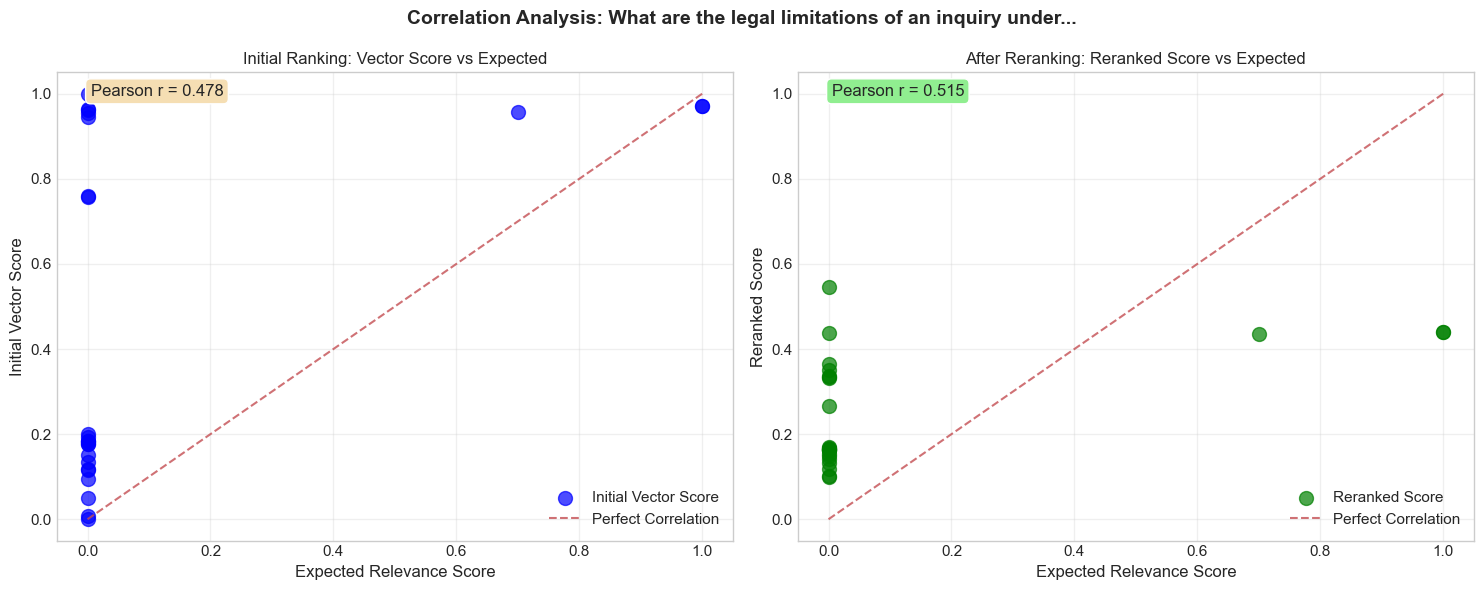

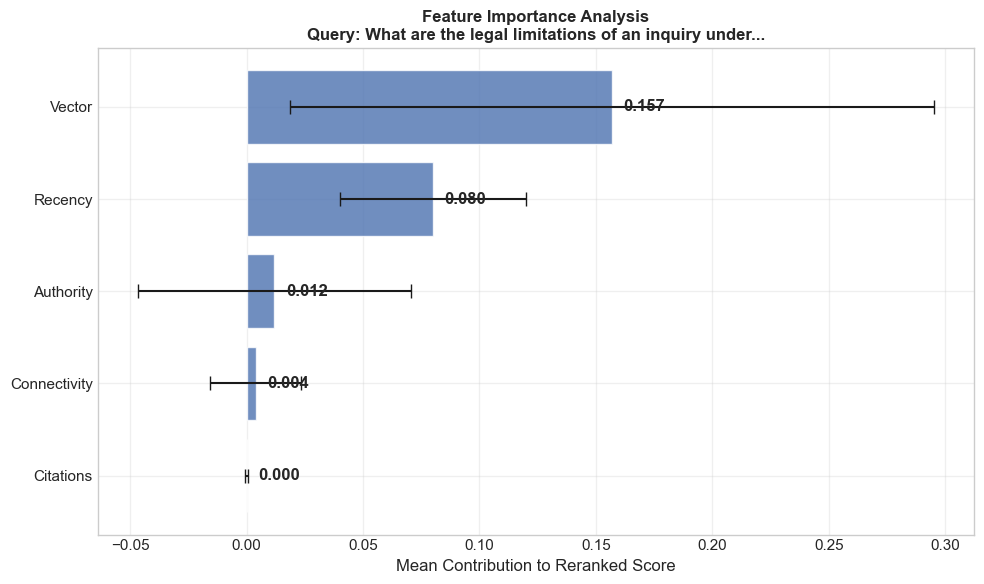

INFO:__main__:System cleanup completed.



------------------------------------------------------------
Query 'What are the legal limitations of an inquiry under Section 9 of the State Lands (Recovery of Possession) Act?' completed successfully
------------------------------------------------------------



In [37]:
import asyncio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple
from enum import Enum
from sentence_transformers import SentenceTransformer
import logging
from datetime import datetime
from neo4j import GraphDatabase
from pinecone import Pinecone
import torch
from transformers import AutoTokenizer, AutoModelForMaskedLM
import nest_asyncio
import firebase_admin
from firebase_admin import credentials, firestore
from IPython.display import display
from sklearn.metrics import ndcg_score, precision_score, recall_score
from scipy.stats import pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')

# --- Configuration ---
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Pinecone credentials
PINECONE_API_KEY = "pcsk_2it9oG_RzRNfQdLGg9jUen7wW6viE9JpLRgVTHtWbTZhomuZKmhuyYnrh8GgMyrHJMz37Q"
PINECONE_CASE_DENSE_INDEX = "law-cases-dense"
PINECONE_CASE_SPARSE_INDEX = "law-cases-sparse"
PINECONE_ACTS_DENSE_INDEX = "law-acts-dense"
PINECONE_ACTS_SPARSE_INDEX = "law-acts-sparse"
PINECONE_DENSE_EMBED_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
PINECONE_SPARSE_EMBED_MODEL = "naver/splade-cocondenser-ensembledistil"

# Neo4j credentials
NEO4J_URI = "neo4j+s://66d16355.databases.neo4j.io"
NEO4J_USERNAME = "neo4j"
NEO4J_PASSWORD = "G4UXZ6KLGd1dzo57rp6ITypJHZ37aM1fn-exAWdw3p8"
NEO4J_DATABASE = "neo4j"

# Firestore credentials
FIRESTORE_PROJECT_ID = "legal-research-platform"
FIRESTORE_CREDENTIALS_PATH = "resources\legal-research-platform-firebase-adminsdk-fbsvc-46a9ab3605.json"

# --- Core Data Structures ---
class DocumentType(Enum):
    CASE = "case"
    ACT = "act"

@dataclass
class Document:
    doc_id: str
    chunk_id: str
    doc_type: DocumentType
    title: str
    content_snippet: str = ""
    
    # Vector scores from different databases
    dense_case_score: float = 0.0
    sparse_case_score: float = 0.0
    dense_act_score: float = 0.0
    sparse_act_score: float = 0.0
    combined_vector_score: float = 0.0
    
    # Knowledge graph features
    citation_count: int = 0
    recency_score: float = 0.0
    authority_score: float = 0.0
    connectivity_score: float = 0.0
    
    # Reranking results
    reranked_score: float = 0.0
    initial_rank: int = 0
    final_rank: int = 0
    expected_score: float = 0.0  # Ground truth relevance score
    
    score_contributions: Dict[str, float] = field(default_factory=dict)

# --- Enhanced Heuristic Reranker ---
class EnhancedHeuristicReranker:
    def __init__(self, weights: Dict[str, float]):
        total_weight = sum(weights.values())
        if total_weight == 0: 
            raise ValueError("Total weight cannot be zero.")
        self.weights = {k: v / total_weight for k, v in weights.items()}
        logger.info(f"Enhanced reranker initialized with normalized weights: {self.weights}")

    def _normalize_scores(self, documents: List[Document], score_field: str) -> None:
        """Normalize scores to 0-1 range using min-max normalization"""
        scores = [getattr(doc, score_field) for doc in documents]
        if not scores or max(scores) == min(scores):
            return
        
        min_score, max_score = min(scores), max(scores)
        for doc in documents:
            normalized = (getattr(doc, score_field) - min_score) / (max_score - min_score)
            setattr(doc, score_field, normalized)

    def rerank(self, documents: List[Document]) -> List[Document]:
        """Enhanced reranking with normalized features and detailed contributions"""
        if not documents:
            return documents
            
        # Set initial ranks based on combined vector score
        documents.sort(key=lambda d: d.combined_vector_score, reverse=True)
        for i, doc in enumerate(documents):
            doc.initial_rank = i + 1

        # Normalize all scoring features
        self._normalize_scores(documents, 'combined_vector_score')
        self._normalize_scores(documents, 'authority_score')
        self._normalize_scores(documents, 'connectivity_score')
        self._normalize_scores(documents, 'recency_score')

        # Calculate reranked scores with detailed contributions
        for doc in documents:
            contrib = {}
            contrib["vector"] = self.weights.get("vector_score", 0) * doc.combined_vector_score
            contrib["authority"] = self.weights.get("authority_score", 0) * doc.authority_score
            contrib["citations"] = self.weights.get("citation_count", 0) * min(doc.citation_count / 100, 1.0)  # Normalize to 0-1
            contrib["recency"] = self.weights.get("recency_score", 0) * doc.recency_score
            contrib["connectivity"] = self.weights.get("connectivity_score", 0) * doc.connectivity_score
            
            doc.score_contributions = contrib
            doc.reranked_score = sum(contrib.values())
            
        # Final sorting and ranking
        documents.sort(key=lambda d: d.reranked_score, reverse=True)
        for i, doc in enumerate(documents):
            doc.final_rank = i + 1
            
        return documents

# --- Enhanced Knowledge Graph Connector ---
class EnhancedKnowledgeGraph:
    def __init__(self, driver):
        self.driver = driver

    def get_features_for_docs(self, doc_ids: List[str]) -> Dict[str, Dict]:
        """Enhanced feature extraction with connectivity metrics"""
        query = """
        UNWIND $doc_ids AS docId
        MATCH (d {doc_id: docId})
        OPTIONAL MATCH (d)<-[:REFERS_TO]-(citing_case)
        WITH d, docId, 
             count(DISTINCT citing_case) AS incomingCitations,
             count(DISTINCT citing_case) AS outgoingCitations,
             count(DISTINCT citing_case) AS totalConnections
        RETURN
            d.doc_id AS doc_id,
            d.title AS title,
            coalesce(d.doc_year, 2020) as year,
            incomingCitations,
            outgoingCitations,
            totalConnections,
            (incomingCitations + outgoingCitations) AS citationCount,
            (incomingCitations * 2.0 + outgoingCitations * 0.5) AS authority_score,
            (totalConnections / 10.0) AS connectivity_score
        """
        
        with self.driver.session(database=NEO4J_DATABASE) as session:
            results = session.run(query, doc_ids=doc_ids)
            feature_map = {}
            current_year = datetime.now().year
            
            for record in results:
                rec_data = record.data()
                years_old = current_year - int(rec_data.get('year', 2020))
                recency = max(0, 1 - (years_old / 50))  # 50-year linear decay
                
                feature_map[rec_data['doc_id']] = {
                    'citation_count': rec_data.get('citationCount', 0),
                    'authority_score': min(rec_data.get('authority_score', 0.0), 100.0),  # Cap at 100
                    'connectivity_score': min(rec_data.get('connectivity_score', 0.0), 5.0),  # Cap at 5
                    'recency_score': recency,
                    'title': rec_data.get('title', 'Untitled'),
                    'doc_type': rec_data.get('doc_type', 'unknown')
                }
        return feature_map

# --- Sparse Vector Encoder ---
class SparseVectorEncoder:
    """Handles sparse vector encoding using SPLADE or TF-IDF methods"""
    
    def __init__(self, model_name: str = PINECONE_SPARSE_EMBED_MODEL):
        self.model_name = model_name
        self.tokenizer = None
        self.model = None
        self._initialize_model()
        
    def _initialize_model(self):
        """Initialize the sparse encoding model"""
        try:
            if "splade" in self.model_name.lower():
                self.tokenizer = AutoTokenizer.from_pretrained(self.model_name)
                self.model = AutoModelForMaskedLM.from_pretrained(self.model_name)
                logger.info(f"Initialized SPLADE model: {self.model_name}")
            else:
                # Fallback to TF-IDF or other sparse methods
                logger.warning(f"Using fallback sparse encoding for: {self.model_name}")
                self.tokenizer = None
                self.model = None
        except Exception as e:
            logger.error(f"Failed to initialize sparse model {self.model_name}: {str(e)}")
            self.tokenizer = None
            self.model = None
    
    def encode_sparse(self, text: str, max_length: int = 512) -> Dict[str, List]:
        """Encode text to sparse vector format"""
        if not self.tokenizer or not self.model:
            return self._fallback_sparse_encoding(text)
            
        try:
            # Use a pre-trained model to embed the text
            inputs = self.tokenizer(text, return_tensors="pt")
            with torch.no_grad():
                outputs = self.model(**inputs).logits.squeeze(0)
            scores = torch.log(1 + torch.relu(outputs))
            max_scores, _ = torch.max(scores, dim=0)
            non_zero_indices = torch.nonzero(max_scores).squeeze(1).tolist()
            non_zero_values = max_scores[non_zero_indices].tolist()
            tokens = tokenizer.convert_ids_to_tokens(non_zero_indices)
            indices = tokenizer.convert_tokens_to_ids(tokens)
            return {
                "values": non_zero_values,
                "indices": indices,
            }
                
        except Exception as e:
            logger.error(f"Error in SPLADE encoding: {str(e)}")
            return self._fallback_sparse_encoding(text)
    
    def _fallback_sparse_encoding(self, text: str) -> Dict[str, List]:
        """Fallback TF-IDF style sparse encoding"""
        try:
            from sklearn.feature_extraction.text import TfidfVectorizer
            import re
            
            # Simple preprocessing
            words = re.findall(r'\b\w+\b', text.lower())
            if not words:
                return {"indices": [], "values": []}
            
            # Create a simple TF-IDF representation
            word_freq = {}
            for word in words:
                word_freq[word] = word_freq.get(word, 0) + 1
            
            # Convert to indices and values (simplified)
            indices = []
            values = []
            for i, (word, freq) in enumerate(sorted(word_freq.items())):
                if freq > 0:
                    indices.append(hash(word) % 30000)  # Simple hash to index
                    values.append(float(freq) / len(words))  # Normalized frequency
            
            return {
                "indices": indices[:100],  # Limit to top 100 terms
                "values": values[:100]
            }
            
        except Exception as e:
            logger.error(f"Fallback sparse encoding failed: {str(e)}")
            return {"indices": [], "values": []}

# --- Multi-Database Vector Search ---
class MultiVectorDB:
    def __init__(self, pinecone_client, dense_model, sparse_encoder=None):
        self.dense_case_index = pinecone_client.Index(PINECONE_CASE_DENSE_INDEX)
        self.sparse_case_index = pinecone_client.Index(PINECONE_CASE_SPARSE_INDEX)
        self.dense_act_index = pinecone_client.Index(PINECONE_ACTS_DENSE_INDEX)
        self.sparse_act_index = pinecone_client.Index(PINECONE_ACTS_SPARSE_INDEX)
        
        self.dense_model = dense_model
        self.sparse_encoder = sparse_encoder or SparseVectorEncoder()
        
    async def search_all_databases(self, query: str, top_k: int = 50) -> Dict[str, List[Dict]]:
        """Search all four vector databases concurrently with appropriate vector types"""
        
        # Generate dense vector
        dense_vector = self.dense_model.encode(query).tolist()
        
        # Generate sparse vector
        sparse_vector = self.sparse_encoder.encode_sparse(query)
        
        # Create search tasks with appropriate vector types
        tasks = [
            asyncio.create_task(self._search_dense_index(self.dense_case_index, dense_vector, top_k, 'dense_case')),
            asyncio.create_task(self._search_sparse_index(self.sparse_case_index, sparse_vector, top_k, 'sparse_case')),
            asyncio.create_task(self._search_dense_index(self.dense_act_index, dense_vector, top_k, 'dense_act')),
            asyncio.create_task(self._search_sparse_index(self.sparse_act_index, sparse_vector, top_k, 'sparse_act'))
        ]
        
        results = await asyncio.gather(*tasks, return_exceptions=True)
        
        return {
            'dense_case': results[0] if not isinstance(results[0], Exception) else [],
            'sparse_case': results[1] if not isinstance(results[1], Exception) else [],
            'dense_act': results[2] if not isinstance(results[2], Exception) else [],
            'sparse_act': results[3] if not isinstance(results[3], Exception) else []
        }
    
    async def _search_dense_index(self, index, query_vector: List[float], top_k: int, db_name: str) -> List[Dict]:
        """Search a dense vector index"""
        try:
            results = index.query(
                vector=query_vector, 
                top_k=top_k, 
                include_metadata=True
            )
            matches = results.get('matches', [])
            
            # Add database source to each match
            for match in matches:
                match['source_db'] = db_name
                match['vector_type'] = 'dense'
            
            logger.info(f"Retrieved {len(matches)} results from {db_name}")
            return matches
            
        except Exception as e:
            logger.error(f"Error searching dense index {db_name}: {str(e)}")
            return []
    
    async def _search_sparse_index(self, index, sparse_vector: Dict[str, List], top_k: int, db_name: str) -> List[Dict]:
        """Search a sparse vector index"""
        try:
            if not sparse_vector.get('indices') or not sparse_vector.get('values'):
                logger.warning(f"Empty sparse vector for {db_name}, skipping search")
                return []
            
            # Pinecone sparse vector format
            sparse_query = {
                'indices': sparse_vector['indices'],
                'values': sparse_vector['values']
            }
            
            results = index.query(
                sparse_vector=sparse_query,
                top_k=top_k,
                include_metadata=True
            )
            matches = results.get('matches', [])
            
            # Add database source to each match
            for match in matches:
                match['source_db'] = db_name
                match['vector_type'] = 'sparse'
            
            logger.info(f"Retrieved {len(matches)} results from {db_name}")
            return matches
            
        except Exception as e:
            logger.error(f"Error searching sparse index {db_name}: {str(e)}")
            # Fallback to dense search if sparse fails
            logger.info(f"Attempting fallback dense search for {db_name}")
            try:
                # Generate a dense vector as fallback
                dense_vector = self.dense_model.encode(" ".join([str(i) for i in sparse_vector.get('indices', [])[:10]])).tolist()
                return await self._search_dense_index(index, dense_vector, top_k, db_name)
            except Exception as fallback_error:
                logger.error(f"Fallback search also failed for {db_name}: {str(fallback_error)}")
                return []

# --- Enhanced Evaluation and Metrics ---
class EnhancedSystemEvaluator:
    def __init__(self):
        self.metrics_history = []
    
    def calculate_ranking_metrics(self, df: pd.DataFrame, k_values: List[int] = [5, 10, 20]) -> Dict[str, float]:
        """Calculate comprehensive ranking metrics"""
        if 'expected_score' not in df.columns or df['expected_score'].sum() == 0:
            return {}
        
        metrics = {}
        
        # Calculate NDCG for different k values
        for k in k_values:
            if len(df) >= k:
                true_relevance = df.head(k)['expected_score'].values
                predicted_scores = df.head(k)['reranked_score'].values
                
                if len(np.unique(true_relevance)) > 1:  # Need variation in relevance
                    ndcg_k = ndcg_score([true_relevance], [predicted_scores])
                    metrics[f'NDCG@{k}'] = ndcg_k
        
        # Calculate correlation metrics
        if len(df) > 1 and df['expected_score'].std() > 0:
            pearson_corr, _ = pearsonr(df['reranked_score'], df['expected_score'])
            spearman_corr, _ = spearmanr(df['reranked_score'], df['expected_score'])
            metrics['Pearson_Correlation'] = pearson_corr
            metrics['Spearman_Correlation'] = spearman_corr
            
            # Initial ranking correlation
            initial_pearson, _ = pearsonr(df['combined_vector_score'], df['expected_score'])
            metrics['Initial_Pearson_Correlation'] = initial_pearson
        
        # Precision and Recall at different k values
        binary_relevance = (df['expected_score'] > 0.5).astype(int)
        if binary_relevance.sum() > 0:
            for k in k_values:
                if len(df) >= k:
                    top_k_relevant = binary_relevance.head(k)
                    precision_k = top_k_relevant.sum() / k
                    recall_k = top_k_relevant.sum() / binary_relevance.sum()
                    metrics[f'Precision@{k}'] = precision_k
                    metrics[f'Recall@{k}'] = recall_k
        
        return metrics

    def display_enhanced_reranking_table(self, query: str, df: pd.DataFrame):
        """Enhanced table with more detailed information"""
        df_display = df.copy()
        
        # Create formatted contribution string
        def format_contributions(row):
            parts = []
            if 'score_contributions' in row and isinstance(row['score_contributions'], dict):
                for k, v in row['score_contributions'].items():
                    parts.append(f"{k.title()}: {v:.3f}")
            return " | ".join(parts)
        
        df_display['Score Breakdown'] = df_display.apply(format_contributions, axis=1)
        df_display['Rank Change'] = df_display['initial_rank'] - df_display['final_rank']
        df_display['Relevance Gap'] = df_display['reranked_score'] - df_display['expected_score']
        
        # Format numeric columns
        numeric_cols = ['combined_vector_score', 'reranked_score', 'expected_score', 'authority_score']
        for col in numeric_cols:
            if col in df_display.columns:
                df_display[col] = df_display[col].map('{:.3f}'.format)
        
        def style_rank_change(val):
            if pd.isna(val):
                return ''
            color = 'green' if val > 0 else 'red' if val < 0 else 'grey'
            return f'color: {color}; font-weight: bold;'
        
        def style_relevance_gap(val):
            if pd.isna(val) or abs(val) < 0.01:
                return ''
            color = 'green' if val > 0 else 'red'
            return f'color: {color}; font-weight: bold;'

        display_cols = [
            'final_rank', 'doc_id', 'doc_type', 'expected_score', 'Rank Change', 
            'initial_rank', 'reranked_score', 'Relevance Gap', 'Score Breakdown'
        ]
        
        available_cols = [col for col in display_cols if col in df_display.columns]
        
        styled_df = df_display[available_cols].rename(columns={
            'final_rank': 'Final Rank', 'doc_id': 'Doc ID', 'doc_type': 'Type',
            'expected_score': 'Expected Score', 'initial_rank': 'Initial Rank', 
            'reranked_score': 'Reranked Score'
        }).style.apply(lambda x: x.map(style_rank_change) if x.name == 'Rank Change' else [''] * len(x), axis=0)\
           .apply(lambda x: x.map(style_relevance_gap) if x.name == 'Relevance Gap' else [''] * len(x), axis=0)\
           .set_properties(**{'text-align': 'center'})\
           .set_properties(subset=['Score Breakdown'], **{'text-align': 'left', 'font-size': '10px'})\
           .set_caption(f"<h3>Enhanced Reranking Results: {query}</h3>")\
           .hide(axis="index")
        
        display(styled_df)

    def plot_correlation_analysis(self, query: str, df: pd.DataFrame):
        """Create correlation scatter plot between calculated and expected scores"""
        if 'expected_score' not in df.columns or df['expected_score'].sum() == 0:
            logger.warning(f"No ground truth scores available for correlation analysis: {query}")
            return
            
        plt.style.use('seaborn-v0_8-whitegrid')
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        
        # Left plot: Initial vs Expected
        axes[0].scatter(df['expected_score'], df['combined_vector_score'], 
                       alpha=0.7, s=100, c='blue', label='Initial Vector Score')
        axes[0].plot([0, 1], [0, 1], 'r--', alpha=0.8, label='Perfect Correlation')
        axes[0].set_xlabel('Expected Relevance Score')
        axes[0].set_ylabel('Initial Vector Score')
        axes[0].set_title('Initial Ranking: Vector Score vs Expected')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Right plot: Reranked vs Expected
        axes[1].scatter(df['expected_score'], df['reranked_score'], 
                       alpha=0.7, s=100, c='green', label='Reranked Score')
        axes[1].plot([0, 1], [0, 1], 'r--', alpha=0.8, label='Perfect Correlation')
        axes[1].set_xlabel('Expected Relevance Score')
        axes[1].set_ylabel('Reranked Score')
        axes[1].set_title('After Reranking: Reranked Score vs Expected')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        # Add correlation coefficients as text
        if len(df) > 1 and df['expected_score'].std() > 0:
            initial_corr, _ = pearsonr(df['combined_vector_score'], df['expected_score'])
            reranked_corr, _ = pearsonr(df['reranked_score'], df['expected_score'])
            
            axes[0].text(0.05, 0.95, f'Pearson r = {initial_corr:.3f}', 
                        transform=axes[0].transAxes, bbox=dict(boxstyle="round", facecolor='wheat'))
            axes[1].text(0.05, 0.95, f'Pearson r = {reranked_corr:.3f}', 
                        transform=axes[1].transAxes, bbox=dict(boxstyle="round", facecolor='lightgreen'))
        
        plt.suptitle(f'Correlation Analysis: {query[:50]}...', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

    def plot_feature_importance(self, query: str, df: pd.DataFrame):
        """Plot feature importance based on score contributions"""
        if df.empty or 'score_contributions' not in df.columns:
            return
            
        # Extract feature contributions
        all_features = set()
        for _, row in df.iterrows():
            if isinstance(row['score_contributions'], dict):
                all_features.update(row['score_contributions'].keys())
        
        if not all_features:
            return
            
        feature_data = []
        for feature in all_features:
            contributions = []
            for _, row in df.iterrows():
                if isinstance(row['score_contributions'], dict):
                    contributions.append(row['score_contributions'].get(feature, 0))
                else:
                    contributions.append(0)
            
            feature_data.append({
                'feature': feature.title(),
                'mean_contribution': np.mean(contributions),
                'std_contribution': np.std(contributions)
            })
        
        feature_df = pd.DataFrame(feature_data).sort_values('mean_contribution', ascending=True)
        
        plt.style.use('seaborn-v0_8-whitegrid')
        fig, ax = plt.subplots(figsize=(10, 6))
        
        bars = ax.barh(feature_df['feature'], feature_df['mean_contribution'], 
                      xerr=feature_df['std_contribution'], capsize=5, alpha=0.8)
        
        ax.set_xlabel('Mean Contribution to Reranked Score')
        ax.set_title(f'Feature Importance Analysis\nQuery: {query[:50]}...', fontweight='bold')
        ax.grid(True, alpha=0.3)
        
        # Add value labels on bars
        for i, bar in enumerate(bars):
            width = bar.get_width()
            ax.text(width + 0.005, bar.get_y() + bar.get_height()/2, 
                   f'{width:.3f}', ha='left', va='center', fontweight='bold')
        
        plt.tight_layout()
        plt.show()

    def display_metrics_summary(self, query: str, metrics: Dict[str, float]):
        """Display comprehensive metrics summary"""
        if not metrics:
            logger.warning(f"No metrics calculated for query: {query}")
            return
            
        metrics_df = pd.DataFrame([
            {'Metric': k, 'Value': f'{v:.4f}' if isinstance(v, float) else str(v)} 
            for k, v in metrics.items()
        ])
        
        styled_metrics = metrics_df.style\
            .set_properties(**{'text-align': 'center'})\
            .set_caption(f"<h3>Performance Metrics: {query}</h3>")\
            .hide(axis="index")
        
        display(styled_metrics)

# --- Enhanced Main RAG System ---
class EnhancedLegalRAGSystem:
    def __init__(self, multi_vector_db, kg, reranker, evaluator):
        self.multi_vector_db = multi_vector_db
        self.kg = kg
        self.reranker = reranker
        self.evaluator = evaluator
        self.ground_truth = {}

    def add_ground_truth_with_scores(self, query: str, doc_scores: Dict[str, float]):
        """Add ground truth with relevance scores (0.0 to 1.0)"""
        self.ground_truth[query] = doc_scores

    def _combine_multi_db_results(self, db_results: Dict[str, List[Dict]]) -> Dict[str, Document]:
        """Combine results from all databases into unified Document objects"""
        doc_map = {}
        
        # Log retrieval statistics
        for db_name, matches in db_results.items():
            logger.info(f"{db_name}: Retrieved {len(matches)} documents")
        
        for db_name, matches in db_results.items():
            for match in matches:
                doc_id = match['id'].split('_')[0]
                if doc_id not in doc_map:
                    metadata = match.get('metadata', {})
                    doc_map[doc_id] = Document(
                        doc_id=doc_id,
                        chunk_id=match.get('id', 'unknown'),
                        doc_type=DocumentType.CASE if 'case' in db_name else DocumentType.ACT,
                        title=metadata.get('title', 'Title Missing'),
                        content_snippet=metadata.get('content', '')[:200] + '...'
                    )
                
                # Assign scores based on database and vector type
                score = match.get('score', 0.0)
                vector_type = match.get('vector_type', 'unknown')
                
                if db_name == 'dense_case':
                    doc_map[doc_id].dense_case_score = score
                elif db_name == 'sparse_case':
                    doc_map[doc_id].sparse_case_score = score
                elif db_name == 'dense_act':
                    doc_map[doc_id].dense_act_score = score
                elif db_name == 'sparse_act':
                    doc_map[doc_id].sparse_act_score = score
                
                logger.debug(f"Doc {doc_id}: {db_name} ({vector_type}) score = {score:.4f}")
        
        # Calculate combined vector scores with improved weighting
        for doc in doc_map.values():
            # Enhanced weighting strategy considering document type and vector type
            case_weight = 0.7 if doc.doc_type == DocumentType.CASE else 0.3
            act_weight = 0.3 if doc.doc_type == DocumentType.CASE else 0.7
            
            # Combine dense and sparse scores with type-aware weighting
            case_combined = (0.6 * doc.dense_case_score + 0.4 * doc.sparse_case_score)
            act_combined = (0.6 * doc.dense_act_score + 0.4 * doc.sparse_act_score)
            
            doc.combined_vector_score = case_weight * case_combined + act_weight * act_combined
            
            logger.debug(f"Doc {doc.doc_id}: Combined score = {doc.combined_vector_score:.4f} "
                        f"(case: {case_combined:.4f}, act: {act_combined:.4f})")
        
        logger.info(f"Combined results: {len(doc_map)} unique documents")
        return doc_map

    async def process_and_evaluate_query(self, query: str, top_k: int = 50) -> Optional[pd.DataFrame]:
        logger.info(f"=== Processing Query: {query} ===")
        
        # Step 1: Search all vector databases
        db_results = await self.multi_vector_db.search_all_databases(query, top_k=top_k)
        
        # Step 2: Combine results from all databases
        doc_map = self._combine_multi_db_results(db_results)
        if not doc_map:
            logger.warning("No documents retrieved from any database")
            return None
        
        # Step 3: Get knowledge graph features
        doc_ids = list(doc_map.keys())
        kg_features = self.kg.get_features_for_docs(doc_ids)

        logger.info(doc_map)
        
        # Step 4: Enhance documents with KG features
        docs_to_rerank = []
        ground_truth_scores = self.ground_truth.get(query, {})
        
        for doc_id, doc in doc_map.items():
            features = kg_features.get(doc_id, {})
            doc.citation_count = features.get('citation_count', 0)
            doc.recency_score = features.get('recency_score', 0.0)
            doc.authority_score = features.get('authority_score', 0.0)
            doc.connectivity_score = features.get('connectivity_score', 0.0)
            doc.expected_score = ground_truth_scores.get(doc_id, 0.0)
            docs_to_rerank.append(doc)
        
        # Step 5: Rerank documents
        reranked_docs = self.reranker.rerank(docs_to_rerank)
        
        # Step 6: Create results DataFrame
        df_results = pd.DataFrame([{
            'doc_id': d.doc_id,
            'doc_type': d.doc_type.value,
            'title': d.title[:50] + '...' if len(d.title) > 50 else d.title,
            'expected_score': d.expected_score,
            'initial_rank': d.initial_rank,
            'final_rank': d.final_rank,
            'combined_vector_score': d.combined_vector_score,
            'reranked_score': d.reranked_score,
            'dense_case_score': d.dense_case_score,
            'sparse_case_score': d.sparse_case_score,
            'dense_act_score': d.dense_act_score,
            'sparse_act_score': d.sparse_act_score,
            'citation_count': d.citation_count,
            'recency_score': d.recency_score,
            'authority_score': d.authority_score,
            'connectivity_score': d.connectivity_score,
            'score_contributions': d.score_contributions
        } for d in reranked_docs])
        
        # Step 7: Calculate metrics and visualize
        metrics = self.evaluator.calculate_ranking_metrics(df_results)
        
        # Display results
        self.evaluator.display_enhanced_reranking_table(query, df_results)
        self.evaluator.display_metrics_summary(query, metrics)
        self.evaluator.plot_correlation_analysis(query, df_results)
        self.evaluator.plot_feature_importance(query, df_results)
        
        return df_results

# --- Main Execution ---
async def main():
    logger.info("Initializing Enhanced Legal RAG System with Sparse Vector Support...")
    
    # Initialize connections and models
    pinecone_client = Pinecone(api_key=PINECONE_API_KEY)
    neo4j_driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USERNAME, NEO4J_PASSWORD))
    
    # Initialize dense and sparse models
    logger.info("Loading dense embedding model...")
    dense_model = SentenceTransformer(PINECONE_DENSE_EMBED_MODEL)
    
    logger.info("Initializing sparse vector encoder...")
    sparse_encoder = SparseVectorEncoder(PINECONE_SPARSE_EMBED_MODEL)
    
    # Initialize system components
    multi_vector_db = MultiVectorDB(pinecone_client, dense_model, sparse_encoder)
    kg = EnhancedKnowledgeGraph(neo4j_driver)
    evaluator = EnhancedSystemEvaluator()
    
    # Enhanced reranker weights
    reranker_weights = {
        "vector_score": 0.35,      # Primary semantic relevance
        "authority_score": 0.30,   # Citation-based authority
        "citation_count": 0.15,    # Raw citation count
        "recency_score": 0.10,     # Document recency
        "connectivity_score": 0.10  # Knowledge graph connectivity
    }
    
    reranker = EnhancedHeuristicReranker(weights=reranker_weights)
    rag_system = EnhancedLegalRAGSystem(multi_vector_db, kg, reranker, evaluator)

    setup_ground_truth(rag_system)
    
    # Define ground truth with relevance scores (0.0 to 1.0)
    # rag_system.add_ground_truth_with_scores(
    #     "precedents for judicial misconduct",
    #     {
    #         '22a85995-df8c-44c2-aa15-3fb84f3c0064': 1.0,  # Highly relevant
    #         # Add more document IDs with their relevance scores
    #         # 'other-doc-id': 0.8,  # Moderately relevant
    #         # 'another-doc-id': 0.3,  # Somewhat relevant
    #     }
    # )
    
    # Test queries
    test_queries = [
        # "precedents for judicial misconduct",
        # "What are the legal principles for dismissing an appeal in a murder case based on a sole eyewitness?",
        # "How does deferment of salary increments affect the calculation of 'satisfactory service' for public officer promotions?",
        "What are the legal limitations of an inquiry under Section 9 of the State Lands (Recovery of Possession) Act?",
        # "Which law prevails in a conflict between the Bail Act No. 30 of 1997 and Section 263 of the Code of Criminal Procedure Act?",
        # "What is the legal standard for corroboration of a victim's video testimony under Section 163A(5) of the Evidence Ordinance?",
        # "Under what conditions is a charitable organization exempt from paying EPF contributions?",
        # "Is a directive from all three commissioners required to commence an investigation under the Bribery Act?",
    ]
    
    # Process each query
    all_results = {}
    for query in test_queries:
        logger.info(f"\n{'='*80}")
        logger.info(f"PROCESSING: {query}")
        logger.info(f"{'='*80}")
        
        try:
            df_result = await rag_system.process_and_evaluate_query(query, top_k=10)
            all_results[query] = df_result
            
            print(f"\n{'-'*60}")
            print(f"Query '{query}' completed successfully")
            print(f"{'-'*60}\n")
            
        except Exception as e:
            logger.error(f"Error processing query '{query}': {str(e)}")
            continue
    
    # Generate comparative analysis across queries
    if len(all_results) > 1:
        logger.info("Generating comparative analysis...")
        generate_comparative_analysis(all_results)
    
    # Cleanup
    neo4j_driver.close()
    logger.info("System cleanup completed.")

def generate_comparative_analysis(results: Dict[str, pd.DataFrame]):
    """Generate comparative analysis across multiple queries"""
    if not results:
        return
        
    plt.style.use('seaborn-v0_8-whitegrid')
    
    # Collect metrics across queries
    query_metrics = []
    for query, df in results.items():
        if df is not None and not df.empty:
            evaluator = EnhancedSystemEvaluator()
            metrics = evaluator.calculate_ranking_metrics(df)
            metrics['Query'] = query[:30] + '...' if len(query) > 30 else query
            query_metrics.append(metrics)
    
    if not query_metrics:
        logger.warning("No valid results for comparative analysis")
        return
    
    # Create comparative metrics DataFrame
    metrics_df = pd.DataFrame(query_metrics)
    
    # Plot 1: Correlation comparison
    if 'Pearson_Correlation' in metrics_df.columns:
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        
        # Initial vs Reranked correlation
        correlation_data = metrics_df[['Query', 'Initial_Pearson_Correlation', 'Pearson_Correlation']].dropna()
        if not correlation_data.empty:
            x = np.arange(len(correlation_data))
            width = 0.35
            
            axes[0].bar(x - width/2, correlation_data['Initial_Pearson_Correlation'], 
                       width, label='Initial Vector Score', alpha=0.8, color='blue')
            axes[0].bar(x + width/2, correlation_data['Pearson_Correlation'], 
                       width, label='Reranked Score', alpha=0.8, color='green')
            
            axes[0].set_xlabel('Queries')
            axes[0].set_ylabel('Pearson Correlation with Ground Truth')
            axes[0].set_title('Ranking Performance: Before vs After Reranking')
            axes[0].set_xticks(x)
            axes[0].set_xticklabels(correlation_data['Query'], rotation=45, ha='right')
            axes[0].legend()
            axes[0].grid(True, alpha=0.3)
            axes[0].axhline(0, color='black', linewidth=0.8)
        
        # NDCG scores comparison
        ndcg_cols = [col for col in metrics_df.columns if 'NDCG@' in col]
        if ndcg_cols:
            ndcg_data = metrics_df[['Query'] + ndcg_cols].dropna()
            if not ndcg_data.empty:
                ndcg_data.set_index('Query')[ndcg_cols].plot(kind='bar', ax=axes[1], alpha=0.8)
                axes[1].set_title('NDCG Scores Across Queries')
                axes[1].set_ylabel('NDCG Score')
                axes[1].legend(title='NDCG@k')
                axes[1].grid(True, alpha=0.3)
                plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')
        
        plt.tight_layout()
        plt.show()
    
    # Plot 2: Performance improvement visualization
    if 'Initial_Pearson_Correlation' in metrics_df.columns and 'Pearson_Correlation' in metrics_df.columns:
        improvement_data = metrics_df[['Query', 'Initial_Pearson_Correlation', 'Pearson_Correlation']].dropna()
        if not improvement_data.empty:
            improvement_data['Improvement'] = (
                improvement_data['Pearson_Correlation'] - improvement_data['Initial_Pearson_Correlation']
            )
            
            plt.figure(figsize=(12, 6))
            colors = ['green' if x > 0 else 'red' for x in improvement_data['Improvement']]
            bars = plt.bar(improvement_data['Query'], improvement_data['Improvement'], 
                          color=colors, alpha=0.7)
            
            plt.axhline(0, color='black', linewidth=1)
            plt.title('Reranking Performance Improvement by Query', fontsize=14, fontweight='bold')
            plt.xlabel('Queries')
            plt.ylabel('Correlation Improvement (Reranked - Initial)')
            plt.xticks(rotation=45, ha='right')
            plt.grid(True, alpha=0.3)
            
            # Add value labels on bars
            for bar, value in zip(bars, improvement_data['Improvement']):
                height = bar.get_height()
                plt.text(bar.get_x() + bar.get_width()/2., height + (0.01 if height > 0 else -0.02),
                        f'{value:.3f}', ha='center', va='bottom' if height > 0 else 'top',
                        fontweight='bold')
            
            plt.tight_layout()
            plt.show()
    
    # Display summary table
    display_cols = ['Query']
    display_cols.extend([col for col in metrics_df.columns if col != 'Query'])
    
    summary_df = metrics_df[display_cols].round(4)
    styled_summary = summary_df.style\
        .set_properties(**{'text-align': 'center'})\
        .set_caption("<h3>Comparative Performance Summary</h3>")\
        .hide(axis="index")
    
    display(styled_summary)
    
    # Calculate and display overall system performance
    numeric_cols = metrics_df.select_dtypes(include=[np.number]).columns
    overall_stats = metrics_df[numeric_cols].agg(['mean', 'std', 'min', 'max']).round(4)
    
    styled_overall = overall_stats.style\
        .set_properties(**{'text-align': 'center'})\
        .set_caption("<h3>Overall System Performance Statistics</h3>")
    
    display(styled_overall)

if __name__ == "__main__":
    nest_asyncio.apply()
    asyncio.run(main())